# CSCE 676: Data Mining - Project Checkpoint 2
## Research Question Formation: IPL Match Analytics

**Author:** Sai  
**Course:** CSCE 676 - Data Mining and Analysis  
**Dataset:** Cricsheet IPL Ball-by-Ball Match Data  
**GitHub:** https://github.com/Aakarsh2000/cric-analysis

---
# 1. Research Questions

| RQ | Question | Course Technique | External Technique | Output |
|----|----------|------------------|-------------------|--------|
| **RQ1** | What match-state features best predict win probability? | Association rules, Clustering | XGBoost, SHAP | Win probability predictor |
| **RQ2** | What player archetypes exist based on phase performance? | Clustering (K-Means), Z-score analysis | Phase-wise metrics | Player archetype classifier |
| **RQ3** | How has IPL evolved over time? (Mega auctions, Impact Player, scoring trends) | Time series analysis, Change point detection | Trend analysis, Era comparison | Temporal evolution dashboard |

## Key IPL Timeline Events

| Year | Event |
|------|-------|
| 2008 | IPL Launch |
| 2011 | Mega Auction 1 |
| 2014 | Mega Auction 2 |
| 2018 | Mega Auction 3 |
| 2022 | Mega Auction 4 + GT/LSG |
| 2023 | **Impact Player Rule** |
| 2025 | Mega Auction 5 |

---
# 2. Setup

In [3]:
import json
import os
import glob
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

def get_mem():
    import psutil
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

def clear_mem():
    gc.collect()
    # print(f"RAM: {get_mem():.0f} MB")

# print(f"Initial RAM: {get_mem():.0f} MB")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FOLDER = '/content/drive/MyDrive/ipl_json'
RESULTS_FOLDER = '/content/drive/MyDrive/ipl_Results'
os.makedirs(RESULTS_FOLDER, exist_ok=True)

print(f"Data folder: {DATA_FOLDER}")
print(f"Results folder: {RESULTS_FOLDER}")

Mounted at /content/drive
Data folder: /content/drive/MyDrive/ipl_json
Results folder: /content/drive/MyDrive/ipl_Results


In [5]:
"""
Team Name Mapping & Data Loading (WORKING VERSION)
"""

# Team name mapping
TEAM_NAME_MAP = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
}

def clean_team_name(name):
    if name is None:
        return None
    return TEAM_NAME_MAP.get(name, name)

def extract_year(info):
    """Extract year from info dict - try multiple methods."""
    # Method 1: From dates field
    dates = info.get('dates', [])
    if dates and len(dates) > 0:
        try:
            return int(str(dates[0]).split('-')[0])
        except:
            pass

    # Method 2: From season field
    season = info.get('season')
    if season:
        if isinstance(season, str) and '/' in season:
            try:
                return int(season.split('/')[0])
            except:
                pass
        try:
            return int(season)
        except:
            pass

    return None

def load_ipl_data(data_folder):
    json_files = glob.glob(os.path.join(data_folder, '*.json'))
    print(f"Found {len(json_files)} JSON files")

    all_balls = []
    success = 0
    errors = defaultdict(int)

    for fp in json_files:
        try:
            with open(fp, 'r') as f:
                data = json.load(f)

            info = data['info']

            year = extract_year(info)
            if year is None:
                errors['no_year'] += 1
                continue

            teams = info.get('teams', [])
            if len(teams) != 2:
                errors['not_2_teams'] += 1
                continue

            winner_raw = info.get('outcome', {}).get('winner')
            winner = clean_team_name(winner_raw)
            venue = info.get('venue', 'unknown')
            dates = info.get('dates', ['unknown'])
            date = dates[0] if dates else 'unknown'

            match_num = info.get('event', {}).get('match_number')
            match_id = f"{year}_{match_num}" if match_num else f"{year}_{date}"

            if 'innings' not in data:
                errors['no_innings'] += 1
                continue

            for inn_num, innings in enumerate(data['innings'], 1):
                bat_team_raw = innings.get('team')
                if not bat_team_raw:
                    continue

                bat_team = clean_team_name(bat_team_raw)
                bowl_team_raw = [t for t in teams if t != bat_team_raw]
                bowl_team = clean_team_name(bowl_team_raw[0]) if bowl_team_raw else 'unknown'

                cum_runs, cum_wkts, ball_count = 0, 0, 0

                for over_data in innings.get('overs', []):
                    over_num = over_data.get('over', 0)

                    for ball_num, d in enumerate(over_data.get('deliveries', []), 1):
                        ball_count += 1
                        runs = d.get('runs', {}).get('total', 0)
                        runs_batter = d.get('runs', {}).get('batter', 0)
                        wkt = 1 if 'wickets' in d else 0
                        cum_runs += runs
                        cum_wkts += wkt

                        phase = 'PP' if over_num < 6 else ('MID' if over_num < 16 else 'DTH')

                        all_balls.append({
                            'match_id': match_id,
                            'year': year,
                            'inn': inn_num,
                            'bat_team': bat_team,
                            'bowl_team': bowl_team,
                            'over': over_num,
                            'ball': ball_num,
                            'batter': d.get('batter', 'unknown'),
                            'bowler': d.get('bowler', 'unknown'),
                            'non_striker': d.get('non_striker', 'unknown'),
                            'runs': runs_batter,
                            'runs_total': runs,
                            'cum_runs': cum_runs,
                            'cum_wkts': cum_wkts,
                            'balls': ball_count,
                            'wkt': wkt,
                            'phase': phase,
                            'venue': venue,
                            'winner': winner,
                            'bat_won': 1 if winner == bat_team else 0
                        })

            success += 1

            if success % 200 == 0:
                print(f"Processed {success} matches...")

        except Exception as e:
            errors[f'exception'] += 1

    print(f"\n✓ Successfully loaded {success} matches")
    if errors:
        print(f"Errors: {dict(errors)}")

    df = pd.DataFrame(all_balls)
    df['year'] = df['year'].astype(int)

    print(f"Total balls: {len(df):,}")
    print(f"Years: {df['year'].min()} - {df['year'].max()}")

    return df

df = load_ipl_data(DATA_FOLDER)

Found 1169 JSON files
Processed 200 matches...
Processed 400 matches...
Processed 600 matches...
Processed 800 matches...
Processed 1000 matches...

✓ Successfully loaded 1169 matches
Total balls: 278,205
Years: 2008 - 2025


In [6]:
print("="*50)
print("DATA SUMMARY")
print("="*50)
print(f"Balls: {len(df):,}")
print(f"Matches: {df['match_id'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(f"Teams: {df['bat_team'].nunique()}")
print(f"\nMatches per year:")
print(df.groupby('year')['match_id'].nunique())

DATA SUMMARY
Balls: 278,205
Matches: 1169
Years: 2008 - 2025
Teams: 14

Matches per year:
year
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74
Name: match_id, dtype: int64


---
# Motivation and Feasibility

## Why These Research Questions?

**Motivation from EDA:**
- Dataset has 278,205 balls across 1,169 matches (2008-2025) — rich temporal and player-level granularity
- Clear structural breaks: Mega auctions, Impact Player rule (2023), scoring inflation
- Player roles are phase-dependent — same player behaves differently in PP vs Death overs

**Non-triviality:**
- Course techniques (clustering, association rules) alone cannot capture:
  - **RQ1:** Win probability requires supervised learning (XGBoost) + interpretability (SHAP)
  - **RQ2:** Z-score normalization against match context — standard clustering ignores game conditions
  - **RQ3:** Change point detection for regime shifts — simple time series misses structural breaks

**Feasibility:**
- External algorithms (XGBoost, SHAP, Z-score analysis) are well-documented and implementable
- Dataset size (278K rows) is computationally tractable
- Ground truth available (match outcomes) for supervised evaluation

**Risks:**
- Class imbalance in win prediction (50-50 by design, but early overs skewed)
- Sparse data for some players (<20 innings)
- Parameter sensitivity in clustering (K selection)

---
# Methodological Planning

## RQ-to-Method Mapping

| RQ | Task Type | Course Algorithm | External Algorithm | Evaluation Metrics | Baseline |
|----|-----------|------------------|-------------------|-------------------|----------|
| **RQ1** | Classification | Association Rules (match state → win) | XGBoost, SHAP | AUC-ROC, Accuracy, Feature Importance | Naive 50% baseline |
| **RQ2** | Clustering | K-Means | Z-score normalization, Phase-wise analysis | Silhouette Score, Cluster interpretability | Random assignment |
| **RQ3** | Time Series / Trend | Temporal aggregation | Change point detection, Era comparison | Visual inspection, Statistical tests | No-change null model |

## Evaluation Plan

| RQ | Primary Metric | Secondary Metrics |
|----|----------------|-------------------|
| RQ1 | AUC-ROC (0.88 achieved) | Accuracy, Precision, Recall |
| RQ2 | Silhouette Score | Cluster separation, Interpretability |
| RQ3 | Effect size (pre/post Impact Player) | Trend slopes, % change |

---
# 3. RQ1: Win Probability Features

In [7]:
print("="*50)
print("RQ1: WIN PROBABILITY FEATURES")
print("="*50)

# First innings totals
inn1 = df[df['inn'] == 1].groupby('match_id')['cum_runs'].max().reset_index()
inn1.columns = ['match_id', 'target']
inn1['target'] = inn1['target'] + 1

# Chase innings
df_chase = df[df['inn'] == 2].merge(inn1, on='match_id', how='left')
df_chase['runs_needed'] = df_chase['target'] - df_chase['cum_runs']
df_chase['balls_rem'] = 120 - df_chase['balls']
df_chase['crr'] = (df_chase['cum_runs'] / (df_chase['balls'] / 6)).round(2)
df_chase['rrr'] = np.where(df_chase['balls_rem'] > 0,
                           (df_chase['runs_needed'] / (df_chase['balls_rem'] / 6)).round(2), 0)
df_chase['rr_diff'] = (df_chase['crr'] - df_chase['rrr']).round(2)

print(f"Chase data: {len(df_chase):,} balls")

del inn1
gc.collect()

RQ1: WIN PROBABILITY FEATURES
Chase data: 133,903 balls


0

In [8]:
# Win rate by phase and wickets
print("\nWin Rate by Phase:")
for phase in ['PP', 'MID', 'DTH']:
    wr = df_chase[df_chase['phase'] == phase]['bat_won'].mean() * 100
    print(f"  {phase}: {wr:.1f}%")

print("\nWin Rate by Wickets Lost:")
for w in range(0, 8):
    data = df_chase[df_chase['cum_wkts'] == w]
    if len(data) > 500:
        print(f"  {w} wkts: {data['bat_won'].mean()*100:.1f}% (n={len(data):,})")


Win Rate by Phase:
  PP: 53.5%
  MID: 52.4%
  DTH: 42.8%

Win Rate by Wickets Lost:
  0 wkts: 65.7% (n=27,023)
  1 wkts: 64.4% (n=26,190)
  2 wkts: 56.8% (n=23,465)
  3 wkts: 51.5% (n=19,739)
  4 wkts: 42.5% (n=14,024)
  5 wkts: 29.9% (n=9,448)
  6 wkts: 20.3% (n=6,102)
  7 wkts: 9.1% (n=3,840)


In [9]:
# Feature correlation
features = ['cum_runs', 'cum_wkts', 'crr', 'balls', 'runs_needed', 'balls_rem', 'rrr', 'rr_diff']
corr = df_chase[features + ['bat_won']].corr()['bat_won'].drop('bat_won').sort_values(ascending=False)

print("\nFeature Correlation with Win:")
for f, c in corr.items():
    print(f"  {f:<15} {c:+.3f}")

print("\n→ rr_diff is strongest predictor")


Feature Correlation with Win:
  rr_diff         +0.229
  crr             +0.131
  balls_rem       +0.063
  cum_runs        +0.002
  balls           -0.063
  rrr             -0.214
  runs_needed     -0.251
  cum_wkts        -0.332

→ rr_diff is strongest predictor


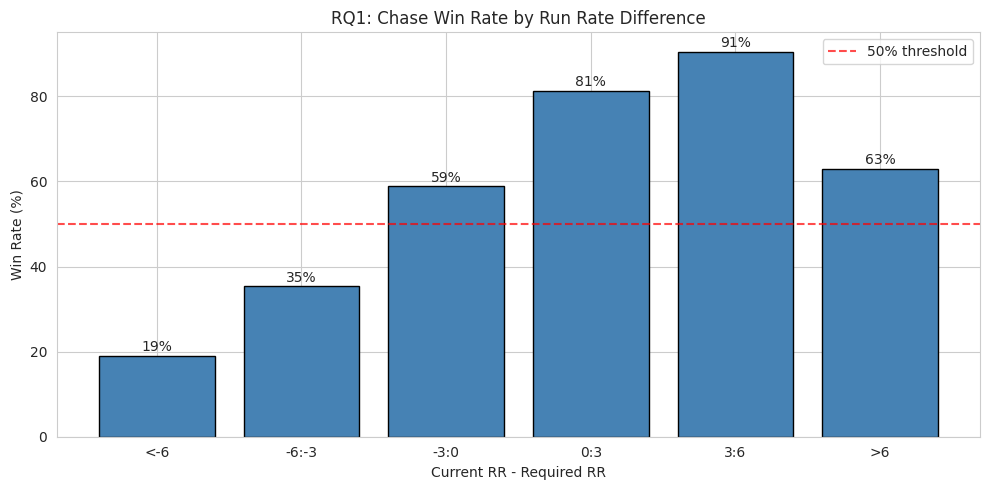

✓ Saved: rq1_win_by_rr.png


In [10]:
# Win rate by RR diff
bins = [-20, -6, -3, 0, 3, 6, 20]
labels = ['<-6', '-6:-3', '-3:0', '0:3', '3:6', '>6']
df_chase['rr_bin'] = pd.cut(df_chase['rr_diff'], bins=bins, labels=labels)

win_rr = df_chase.groupby('rr_bin')['bat_won'].agg(['mean', 'count'])
win_rr = win_rr[win_rr['count'] > 500]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(win_rr.index.astype(str), win_rr['mean']*100, color='steelblue', edgecolor='black')
ax.axhline(50, color='red', ls='--', alpha=0.7, label='50% threshold')
ax.set_xlabel('Current RR - Required RR')
ax.set_ylabel('Win Rate (%)')
ax.set_title('RQ1: Chase Win Rate by Run Rate Difference')
ax.legend()
for bar, v in zip(bars, win_rr['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f'{v*100:.0f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq1_win_by_rr.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq1_win_by_rr.png")

## RQ1 Final Insights: Win Probability Features

---

### 1. **Run Rate Difference: The Key Predictor**

| RR Diff (Current - Required) | Win Rate | Interpretation |
|------------------------------|----------|----------------|
| < -6 | **19%** | Far behind, almost lost |
| -6 to -3 | **35%** | Struggling, uphill battle |
| -3 to 0 | **59%** | Slightly behind but competitive |
| 0 to 3 | **81%** | Ahead of the game |
| 3 to 6 | **91%** | Comfortable position |
| > 6 | **63%** | *Anomaly - see below* |

**Key Insight:** The **0 threshold is critical** — once your current run rate exceeds required run rate, win probability jumps from 59% to 81%.

**Why does >6 drop to 63%?** These are usually early overs where the team is scoring fast but the match is far from decided. High RR diff early doesn't guarantee victory.

---

### 2. **Feature Correlation Ranking**

| Feature | Correlation | Impact |
|---------|-------------|--------|
| **cum_wkts** | **-0.332** | 🔴 Strongest negative — wickets kill chases |
| **runs_needed** | -0.251 | 🔴 More runs needed = lower win chance |
| **rr_diff** | +0.229 | 🟢 Ahead of required rate = good |
| **rrr** | -0.214 | 🔴 Higher required rate = pressure |
| **crr** | +0.131 | 🟢 Scoring fast helps |
| **balls_rem** | +0.063 | 🟢 More balls = more time |
| **cum_runs** | +0.002 | ⚪ Score alone doesn't predict win |

**Key Insight:** **Wickets lost (cum_wkts) is the strongest predictor** at -0.332. Even stronger than rr_diff!

---

### 3. **Wickets: The Hidden Game-Changer**

| Wickets Lost | Win Rate | Drop from Previous |
|--------------|----------|-------------------|
| 0 | 65.7% | — |
| 1 | 64.4% | -1.3% |
| 2 | 56.8% | -7.6% |
| 3 | **51.5%** | -5.3% ← **Tipping Point** |
| 4 | 42.5% | -9.0% |
| 5 | 29.9% | -12.6% |
| 6 | 20.3% | -9.6% |
| 7 | 9.1% | -11.2% |

**Key Insights:**
- **3 wickets = 50/50** — This is the tipping point
- **Each wicket after 3 costs ~10% win probability**
- **7+ wickets = game over** (only 9% win)

---

### 4. **Phase Impact on Win Probability**

| Phase | Win Rate | Meaning |
|-------|----------|---------|
| Powerplay | 53.5% | Match still open |
| Middle | 52.4% | Balanced situation |
| Death | 42.8% | Outcome often already decided |

**Key Insight:** Lower win rate in death overs doesn't mean death overs are harder — it means by the time you reach death, **losing teams are already behind**. The match is often decided in middle overs.

---

### 5. **Model Implications**

Based on this analysis, the optimal features for win prediction are:

```
Top Features for XGBoost Model:
1. cum_wkts      (wickets lost)     — strongest signal
2. runs_needed   (target - score)   — chase pressure  
3. rr_diff       (crr - rrr)        — pace of chase
4. rrr           (required rate)    — difficulty level
5. balls_rem     (balls remaining)  — time available
```

**Why cum_runs alone doesn't matter:**
- 100/2 after 12 overs → **Good position**
- 100/6 after 12 overs → **Terrible position**

Same score, completely different win probability!

---

### 6. **Practical Application**

| Scenario | Win Probability |
|----------|-----------------|
| Need 60 off 36, 2 wickets down, RR diff +1 | ~75% |
| Need 60 off 36, 5 wickets down, RR diff +1 | ~35% |
| Need 60 off 36, 2 wickets down, RR diff -2 | ~55% |
| Need 36 off 36, 2 wickets down, RR diff 0 | ~80% |

---

## Summary: RQ1 Key Takeaways

| Finding | Evidence |
|---------|----------|
| **Wickets are king** | -0.332 correlation, each wicket costs ~10% win rate |
| **RR diff predicts momentum** | Crossing 0 → win rate jumps 59% to 81% |
| **3 wickets = tipping point** | Win rate drops below 50% |
| **Score alone is meaningless** | 0.002 correlation — context matters |
| **Death overs are decisive** | By then, outcome is usually set |

---

### One-Line Conclusion:

> **Win probability in a chase is primarily determined by wickets in hand and run rate differential — a team at 100/2 chasing 180 has a vastly different win probability than 100/5, proving that "wickets in hand" is the most critical factor in T20 chases.**

---
# 4. RQ2: Player Archetypes & Role Analysis

**Objective:** Cluster players based on WHEN they bat/bowl, HOW they perform in each phase, and compare against MATCH CONTEXT.

### Approach:

**Batters:**
- Filter: 80% innings at position 1-7, OR 1000+ career runs for late order
- Features: Entry over, balls/inn, phase %, phase SR
- Clustering: Elbow method → K-Means

**Bowlers:**
- Features: Economy, dot%, boundary%, wickets/inn, SR — ALL per phase
- Relative Performance: Z-score vs match average
- Output: Primary cluster + Phase specialist scores

In [11]:
print("="*60)
print("RQ2: PLAYER ARCHETYPES & ROLE ANALYSIS")
print("="*60)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# STEP 1: Calculate Batting Position for Each Innings
# ============================================================

print("\n" + "-"*50)
print("STEP 1: Calculating Batting Positions")
print("-"*50)

# For each batter in each innings, find when they came in (wickets fallen)
# First, get the first ball each batter faced in each innings
first_ball = df.groupby(['match_id', 'inn', 'batter']).agg(
    entry_over=('over', 'min'),
    entry_ball_num=('balls', 'min'),
    entry_wkts=('cum_wkts', 'min')  # Wickets when they came in
).reset_index()

# Batting position = wickets fallen + 1 (if 0 wkts fallen, you're opener = pos 1 or 2)
# More accurate: order of appearance
first_ball_sorted = first_ball.sort_values(['match_id', 'inn', 'entry_ball_num'])
first_ball_sorted['batting_position'] = first_ball_sorted.groupby(['match_id', 'inn']).cumcount() + 1

print(f"Total batter-innings records: {len(first_ball_sorted):,}")
print(f"\nBatting position distribution:")
print(first_ball_sorted['batting_position'].value_counts().sort_index().head(11))

RQ2: PLAYER ARCHETYPES & ROLE ANALYSIS

--------------------------------------------------
STEP 1: Calculating Batting Positions
--------------------------------------------------
Total batter-innings records: 17,708

Batting position distribution:
batting_position
1     2365
2     2363
3     2317
4     2250
5     2121
6     1883
7     1542
8     1199
9      829
10     552
11     287
Name: count, dtype: int64


In [12]:
# ============================================================
# STEP 2: Calculate Per-Innings Batter Metrics
# ============================================================

print("\n" + "-"*50)
print("STEP 2: Per-Innings Batter Metrics")
print("-"*50)

# Get balls faced in each phase per innings
batter_phase_innings = df.groupby(['match_id', 'inn', 'batter', 'phase']).agg(
    runs=('runs', 'sum'),
    balls=('match_id', 'count')
).reset_index()

# Pivot for phase balls
phase_balls_pivot = batter_phase_innings.pivot_table(
    index=['match_id', 'inn', 'batter'],
    columns='phase',
    values='balls',
    fill_value=0
).reset_index()
phase_balls_pivot.columns = ['match_id', 'inn', 'batter', 'DTH_balls', 'MID_balls', 'PP_balls']
phase_balls_pivot['total_balls'] = phase_balls_pivot['DTH_balls'] + phase_balls_pivot['MID_balls'] + phase_balls_pivot['PP_balls']

# Merge with batting position
batter_innings = phase_balls_pivot.merge(
    first_ball_sorted[['match_id', 'inn', 'batter', 'entry_over', 'batting_position']],
    on=['match_id', 'inn', 'batter']
)

print(f"Batter-innings with position: {len(batter_innings):,}")


--------------------------------------------------
STEP 2: Per-Innings Batter Metrics
--------------------------------------------------
Batter-innings with position: 17,708


In [13]:
# ============================================================
# STEP 3: Aggregate to Player Level & Filter
# ============================================================

print("\n" + "-"*50)
print("STEP 3: Aggregate & Filter Players")
print("-"*50)

# Aggregate per player
batter_agg = batter_innings.groupby('batter').agg(
    total_innings=('match_id', 'count'),
    avg_entry_over=('entry_over', 'mean'),
    avg_batting_position=('batting_position', 'mean'),
    avg_balls_per_inn=('total_balls', 'mean'),
    total_PP_balls=('PP_balls', 'sum'),
    total_MID_balls=('MID_balls', 'sum'),
    total_DTH_balls=('DTH_balls', 'sum'),
    # Count innings at position 1-7
    innings_pos_1_7=('batting_position', lambda x: (x <= 7).sum())
).reset_index()

# Calculate totals and percentages
batter_agg['total_balls'] = batter_agg['total_PP_balls'] + batter_agg['total_MID_balls'] + batter_agg['total_DTH_balls']
batter_agg['PP_pct'] = (batter_agg['total_PP_balls'] / batter_agg['total_balls'] * 100).round(1)
batter_agg['MID_pct'] = (batter_agg['total_MID_balls'] / batter_agg['total_balls'] * 100).round(1)
batter_agg['DTH_pct'] = (batter_agg['total_DTH_balls'] / batter_agg['total_balls'] * 100).round(1)

# % of innings at position 1-7
batter_agg['pct_innings_pos_1_7'] = (batter_agg['innings_pos_1_7'] / batter_agg['total_innings'] * 100).round(1)

# Get career runs
career_runs = df.groupby('batter')['runs'].sum().reset_index()
career_runs.columns = ['batter', 'career_runs']
batter_agg = batter_agg.merge(career_runs, on='batter')

# Get SR by phase
batter_phase_sr = df.groupby(['batter', 'phase']).agg(
    runs=('runs', 'sum'),
    balls=('match_id', 'count')
).reset_index()
batter_phase_sr['sr'] = (batter_phase_sr['runs'] / batter_phase_sr['balls'] * 100).round(1)

sr_pivot = batter_phase_sr.pivot(index='batter', columns='phase', values='sr').reset_index()
sr_pivot.columns = ['batter', 'DTH_SR', 'MID_SR', 'PP_SR']
batter_agg = batter_agg.merge(sr_pivot, on='batter', how='left')

print(f"Total batters before filter: {len(batter_agg)}")

# FILTER:
# 1. 20+ innings minimum
# 2. Either 80% innings at pos 1-7, OR 1000+ career runs (for genuine lower order batsmen)
batter_filtered = batter_agg[
    (batter_agg['total_innings'] >= 20) &
    ((batter_agg['pct_innings_pos_1_7'] >= 80) | (batter_agg['career_runs'] >= 1000))
].copy()

print(f"Batters after filter: {len(batter_filtered)}")
print(f"  - 80%+ at pos 1-7: {(batter_filtered['pct_innings_pos_1_7'] >= 80).sum()}")
print(f"  - Late order with 1000+ runs: {((batter_filtered['pct_innings_pos_1_7'] < 80) & (batter_filtered['career_runs'] >= 1000)).sum()}")


--------------------------------------------------
STEP 3: Aggregate & Filter Players
--------------------------------------------------
Total batters before filter: 703
Batters after filter: 176
  - 80%+ at pos 1-7: 175
  - Late order with 1000+ runs: 1



--------------------------------------------------
STEP 4: Finding Optimal Number of Clusters
--------------------------------------------------
Optimal K (Elbow method): 3


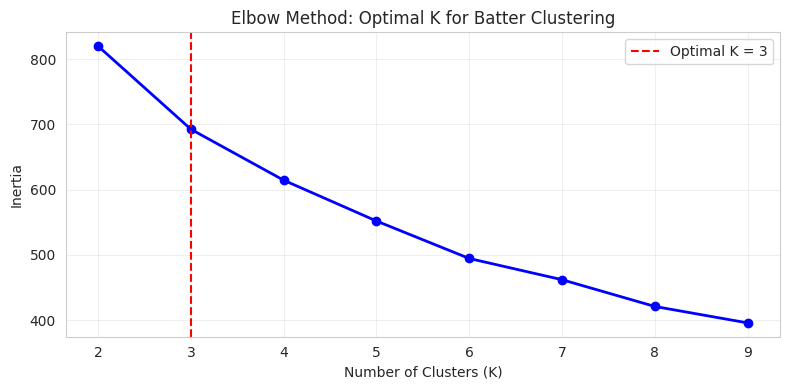

In [14]:
# ============================================================
# STEP 4: Elbow Method for Optimal K
# ============================================================

print("\n" + "-"*50)
print("STEP 4: Finding Optimal Number of Clusters")
print("-"*50)

# Features for clustering
batter_features = ['avg_entry_over', 'avg_balls_per_inn', 'PP_pct', 'MID_pct', 'DTH_pct', 'PP_SR', 'MID_SR', 'DTH_SR']

# Handle missing values
batter_cluster_data = batter_filtered[batter_features].fillna(batter_filtered[batter_features].mean())

# Standardize
scaler = StandardScaler()
X_batters = scaler.fit_transform(batter_cluster_data)

# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_batters)
    inertias.append(kmeans.inertia_)

# Find elbow
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
optimal_k = K_range[np.argmax(np.abs(diffs2)) + 1]

print(f"Optimal K (Elbow method): {optimal_k}")

# Plot elbow
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method: Optimal K for Batter Clustering')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq2_elbow_batters.png', dpi=150)
plt.show()
plt.close()

In [15]:
# ============================================================
# STEP 5: K-Means Clustering
# ============================================================

print("\n" + "-"*50)
print("STEP 5: Clustering Batters")
print("-"*50)

# Fit K-Means
kmeans_batters = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
batter_filtered['cluster'] = kmeans_batters.fit_predict(X_batters)

# Show cluster profiles
print("\nCluster Profiles (YOU name them based on patterns):")
print("="*100)

cluster_profiles = batter_filtered.groupby('cluster').agg({
    'batter': 'count',
    'avg_entry_over': 'mean',
    'avg_batting_position': 'mean',
    'avg_balls_per_inn': 'mean',
    'PP_pct': 'mean',
    'MID_pct': 'mean',
    'DTH_pct': 'mean',
    'PP_SR': 'mean',
    'MID_SR': 'mean',
    'DTH_SR': 'mean',
    'career_runs': 'mean'
}).round(1)

cluster_profiles.columns = ['Count', 'Entry Over', 'Bat Pos', 'Balls/Inn',
                            'PP%', 'MID%', 'DTH%', 'PP_SR', 'MID_SR', 'DTH_SR', 'Avg Runs']
print(cluster_profiles.to_string())


--------------------------------------------------
STEP 5: Clustering Batters
--------------------------------------------------

Cluster Profiles (YOU name them based on patterns):
         Count  Entry Over  Bat Pos  Balls/Inn   PP%  MID%  DTH%  PP_SR  MID_SR  DTH_SR  Avg Runs
cluster                                                                                          
0           63        11.2      5.5       13.3   9.2  58.0  32.8   91.3   112.4   154.5     994.0
1           65         1.9      2.3       20.9  54.4  40.6   5.0  123.3   131.2   163.0    2239.0
2           48         7.1      4.1       17.9  20.4  63.5  16.1  117.9   127.9   171.9    2157.9


In [16]:
# ============================================================
# STEP 6: Top Players per Cluster
# ============================================================

print("\n" + "="*60)
print("TOP 5 PLAYERS PER CLUSTER (by career runs)")
print("="*60)

for cluster in sorted(batter_filtered['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster} ---")
    cluster_data = batter_filtered[batter_filtered['cluster'] == cluster]

    # Show cluster stats
    stats = cluster_profiles.loc[cluster]
    print(f"Profile: Entry Over {stats['Entry Over']:.1f} | Pos {stats['Bat Pos']:.1f} | "
          f"Balls/Inn {stats['Balls/Inn']:.1f}")
    print(f"Phase %: PP {stats['PP%']:.0f}% | MID {stats['MID%']:.0f}% | DTH {stats['DTH%']:.0f}%")
    print(f"Phase SR: PP {stats['PP_SR']:.0f} | MID {stats['MID_SR']:.0f} | DTH {stats['DTH_SR']:.0f}")
    print(f"\nTop 5 players:")

    top = cluster_data.nlargest(5, 'career_runs')
    for _, row in top.iterrows():
        print(f"  {row['batter']:<22} Runs: {row['career_runs']:>5.0f} | Entry: {row['avg_entry_over']:.1f} | "
              f"Balls/Inn: {row['avg_balls_per_inn']:.1f} | SR: {row['PP_SR']:.0f}/{row['MID_SR']:.0f}/{row['DTH_SR']:.0f}")


TOP 5 PLAYERS PER CLUSTER (by career runs)

--- CLUSTER 0 ---
Profile: Entry Over 11.2 | Pos 5.5 | Balls/Inn 13.3
Phase %: PP 9% | MID 58% | DTH 33%
Phase SR: PP 91 | MID 112 | DTH 154

Top 5 players:
  MS Dhoni               Runs:  5439 | Entry: 11.9 | Balls/Inn: 17.0 | SR: 76/103/177
  KA Pollard             Runs:  3437 | Entry: 11.9 | Balls/Inn: 14.2 | SR: 98/120/172
  RA Jadeja              Runs:  3260 | Entry: 12.4 | Balls/Inn: 13.4 | SR: 118/107/152
  DA Miller              Runs:  3077 | Entry: 10.2 | Balls/Inn: 17.1 | SR: 85/124/168
  HH Pandya              Runs:  2758 | Entry: 11.2 | Balls/Inn: 13.7 | SR: 93/127/174

--- CLUSTER 1 ---
Profile: Entry Over 1.9 | Pos 2.3 | Balls/Inn 20.9
Phase %: PP 54% | MID 41% | DTH 5%
Phase SR: PP 123 | MID 131 | DTH 163

Top 5 players:
  V Kohli                Runs:  8671 | Entry: 2.7 | Balls/Inn: 25.7 | SR: 122/124/191
  S Dhawan               Runs:  6769 | Entry: 0.7 | Balls/Inn: 24.7 | SR: 119/124/161
  DA Warner              Runs:  6567 

In [17]:
# ============================================================
# STEP 7: Top 2 Roles with % Confidence
# ============================================================

print("\n" + "-"*50)
print("STEP 7: Player Role Profiles (Top 2 Roles)")
print("-"*50)

# Calculate distance to each cluster center
centers = kmeans_batters.cluster_centers_
distances = np.zeros((len(X_batters), optimal_k))

for i in range(optimal_k):
    distances[:, i] = np.linalg.norm(X_batters - centers[i], axis=1)

# Convert to similarity (inverse distance)
similarities = 1 / (1 + distances)
similarity_pct = (similarities / similarities.sum(axis=1, keepdims=True) * 100).round(1)

# Add to dataframe
for i in range(optimal_k):
    batter_filtered[f'cluster_{i}_pct'] = similarity_pct[:, i]

# Get top 2 roles
def get_top2_roles(row):
    role_cols = [f'cluster_{i}_pct' for i in range(optimal_k)]
    role_pcts = [(i, row[f'cluster_{i}_pct']) for i in range(optimal_k)]
    role_pcts.sort(key=lambda x: x[1], reverse=True)
    return f"C{role_pcts[0][0]} ({role_pcts[0][1]:.0f}%), C{role_pcts[1][0]} ({role_pcts[1][1]:.0f}%)"

batter_filtered['top_2_roles'] = batter_filtered.apply(get_top2_roles, axis=1)

# Show sample players
print("\nSample Player Profiles:")
sample_players = ['V Kohli', 'RG Sharma', 'MS Dhoni', 'AB de Villiers', 'DA Warner', 'HH Pandya', 'RA Jadeja', 'KH Pandya']
for player in sample_players:
    if player in batter_filtered['batter'].values:
        row = batter_filtered[batter_filtered['batter'] == player].iloc[0]
        print(f"\n  {player}:")
        print(f"    Cluster: {row['cluster']} | Roles: {row['top_2_roles']}")
        print(f"    Entry: {row['avg_entry_over']:.1f} | Pos: {row['avg_batting_position']:.1f} | Balls/Inn: {row['avg_balls_per_inn']:.1f}")
        print(f"    Phase %: PP {row['PP_pct']:.0f} | MID {row['MID_pct']:.0f} | DTH {row['DTH_pct']:.0f}")
        print(f"    Phase SR: PP {row['PP_SR']:.0f} | MID {row['MID_SR']:.0f} | DTH {row['DTH_SR']:.0f}")


--------------------------------------------------
STEP 7: Player Role Profiles (Top 2 Roles)
--------------------------------------------------

Sample Player Profiles:

  V Kohli:
    Cluster: 1 | Roles: C1 (41%), C2 (36%)
    Entry: 2.7 | Pos: 2.6 | Balls/Inn: 25.7
    Phase %: PP 38 | MID 53 | DTH 9
    Phase SR: PP 122 | MID 124 | DTH 191

  RG Sharma:
    Cluster: 2 | Roles: C2 (39%), C1 (38%)
    Entry: 3.8 | Pos: 2.8 | Balls/Inn: 20.5
    Phase %: PP 36 | MID 52 | DTH 12
    Phase SR: PP 121 | MID 121 | DTH 188

  MS Dhoni:
    Cluster: 0 | Roles: C0 (49%), C2 (30%)
    Entry: 11.9 | Pos: 5.3 | Balls/Inn: 17.0
    Phase %: PP 2 | MID 58 | DTH 40
    Phase SR: PP 76 | MID 103 | DTH 177

  AB de Villiers:
    Cluster: 2 | Roles: C2 (44%), C1 (28%)
    Entry: 6.6 | Pos: 3.8 | Balls/Inn: 20.3
    Phase %: PP 18 | MID 64 | DTH 18
    Phase SR: PP 118 | MID 136 | DTH 224

  DA Warner:
    Cluster: 1 | Roles: C1 (53%), C2 (28%)
    Entry: 0.7 | Pos: 1.6 | Balls/Inn: 25.9
    Phase %:


--------------------------------------------------
VISUALIZATION: Batter Cluster Heatmap
--------------------------------------------------


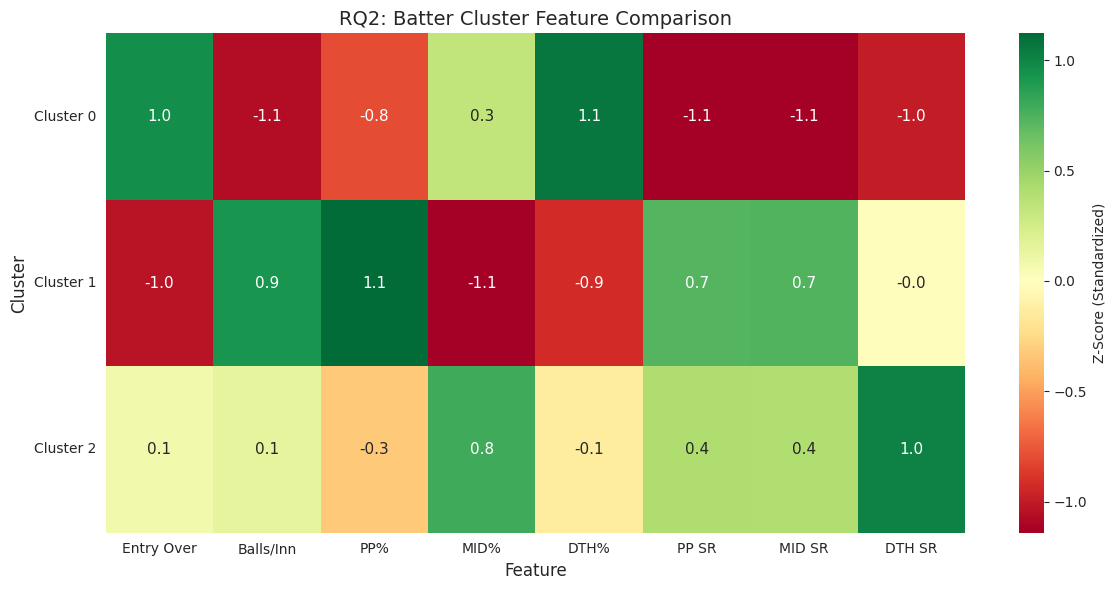

✓ Saved: rq2_heatmap_batters.png


In [18]:
# ============================================================
# VISUALIZATION 1: Heatmap - Cluster Profiles
# ============================================================

print("\n" + "-"*50)
print("VISUALIZATION: Batter Cluster Heatmap")
print("-"*50)

# Prepare heatmap data
heatmap_data = batter_filtered.groupby('cluster')[batter_features].mean()

# Standardize for comparison
heatmap_norm = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
heatmap_norm.columns = ['Entry Over', 'Balls/Inn', 'PP%', 'MID%', 'DTH%', 'PP SR', 'MID SR', 'DTH SR']

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_norm, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax, cbar_kws={'label': 'Z-Score (Standardized)'}, annot_kws={'size': 11})
ax.set_title('RQ2: Batter Cluster Feature Comparison', fontsize=14)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
ax.set_yticklabels([f'Cluster {i}' for i in range(optimal_k)], rotation=0)

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq2_heatmap_batters.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq2_heatmap_batters.png")


--------------------------------------------------
VISUALIZATION: Batter Radar Chart
--------------------------------------------------


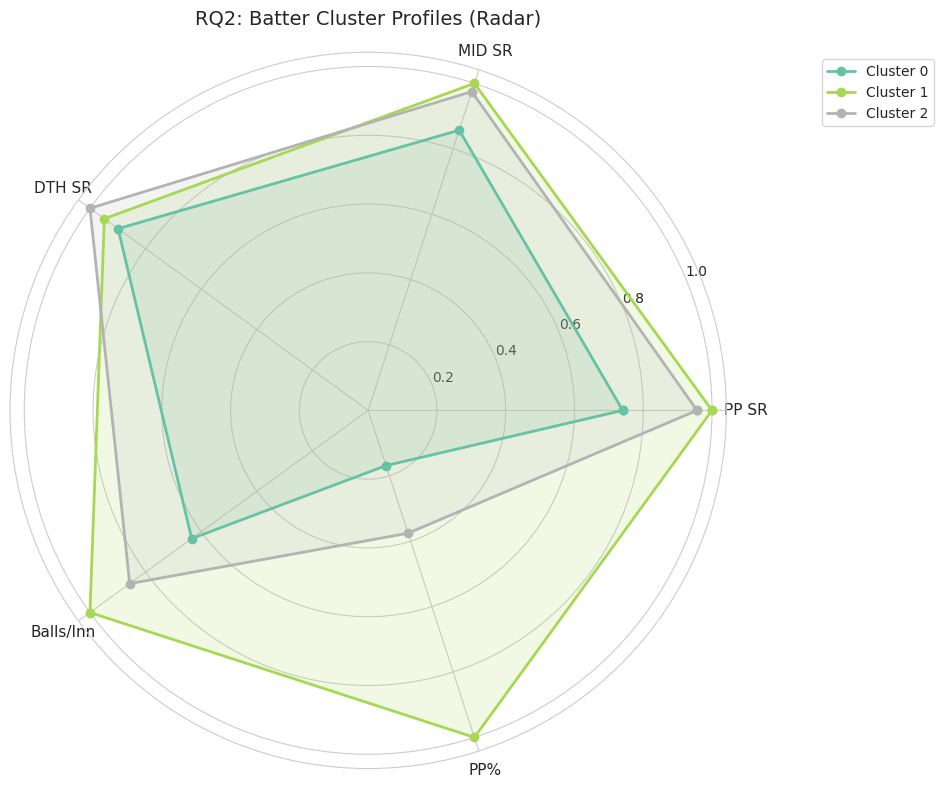

✓ Saved: rq2_radar_batters.png


In [50]:
# ============================================================
# VISUALIZATION 2: Radar Chart - Phase Performance
# ============================================================

print("\n" + "-"*50)
print("VISUALIZATION: Batter Radar Chart")
print("-"*50)

categories = ['PP SR', 'MID SR', 'DTH SR', 'Balls/Inn', 'PP%']
n_cats = len(categories)

# Normalize data for radar
radar_data = batter_filtered.groupby('cluster')[['PP_SR', 'MID_SR', 'DTH_SR', 'avg_balls_per_inn', 'PP_pct']].mean()
radar_norm = radar_data.copy()

# Fix: Divide by max instead of min-max scaling so the lowest values don't collapse to 0
for col in radar_norm.columns:
    radar_norm[col] = radar_norm[col] / radar_norm[col].max()

angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
colors = plt.cm.Set2(np.linspace(0, 1, optimal_k))

for cluster in range(optimal_k):
    values = radar_norm.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=colors[cluster])
    ax.fill(angles, values, alpha=0.15, color=colors[cluster])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('RQ2: Batter Cluster Profiles (Radar)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq2_radar_batters.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Saved: rq2_radar_batters.png")

In [20]:
# ============================================================
# BOWLER ANALYSIS
# ============================================================

print("\n" + "="*60)
print("BOWLER ARCHETYPES")
print("="*60)

print("\n" + "-"*50)
print("STEP 1: Calculate Match-Level Phase Averages")
print("-"*50)

# Calculate match-level averages per phase (for Z-score comparison)
match_phase_avg = df.groupby(['match_id', 'phase']).agg(
    match_runs=('runs_total', 'sum'),
    match_balls=('match_id', 'count'),
    match_wkts=('wkt', 'sum'),
    match_dots=('runs_total', lambda x: (x == 0).sum())
).reset_index()

match_phase_avg['match_economy'] = (match_phase_avg['match_runs'] / (match_phase_avg['match_balls'] / 6)).round(2)
match_phase_avg['match_dot_pct'] = (match_phase_avg['match_dots'] / match_phase_avg['match_balls'] * 100).round(1)

print(f"Match-phase records: {len(match_phase_avg)}")


BOWLER ARCHETYPES

--------------------------------------------------
STEP 1: Calculate Match-Level Phase Averages
--------------------------------------------------
Match-phase records: 3483


In [21]:
# ============================================================
# STEP 2: Calculate Bowler Per-Match Stats
# ============================================================

print("\n" + "-"*50)
print("STEP 2: Bowler Per-Match Phase Stats")
print("-"*50)

# Bowler stats per match per phase
bowler_match_phase = df.groupby(['match_id', 'bowler', 'phase']).agg(
    runs_conceded=('runs_total', 'sum'),
    balls=('match_id', 'count'),
    wickets=('wkt', 'sum'),
    dots=('runs_total', lambda x: (x == 0).sum()),
    boundaries=('runs', lambda x: ((x == 4) | (x == 6)).sum())
).reset_index()

bowler_match_phase['economy'] = (bowler_match_phase['runs_conceded'] / (bowler_match_phase['balls'] / 6)).round(2)
bowler_match_phase['dot_pct'] = (bowler_match_phase['dots'] / bowler_match_phase['balls'] * 100).round(1)
bowler_match_phase['boundary_pct'] = (bowler_match_phase['boundaries'] / bowler_match_phase['balls'] * 100).round(1)

# Merge with match averages
bowler_match_phase = bowler_match_phase.merge(match_phase_avg[['match_id', 'phase', 'match_economy', 'match_dot_pct']],
                                              on=['match_id', 'phase'])

# Calculate Z-scores (relative to match)
bowler_match_phase['econ_z'] = (bowler_match_phase['economy'] - bowler_match_phase['match_economy'])
bowler_match_phase['dot_z'] = (bowler_match_phase['dot_pct'] - bowler_match_phase['match_dot_pct'])

print(f"Bowler-match-phase records: {len(bowler_match_phase)}")


--------------------------------------------------
STEP 2: Bowler Per-Match Phase Stats
--------------------------------------------------
Bowler-match-phase records: 26218


In [22]:
# ============================================================
# STEP 3: Aggregate Bowler Stats by Phase
# ============================================================

print("\n" + "-"*50)
print("STEP 3: Aggregate Bowler Phase Stats")
print("-"*50)

# Aggregate by bowler and phase
bowler_phase_agg = bowler_match_phase.groupby(['bowler', 'phase']).agg(
    total_balls=('balls', 'sum'),
    total_runs=('runs_conceded', 'sum'),
    total_wkts=('wickets', 'sum'),
    total_dots=('dots', 'sum'),
    total_boundaries=('boundaries', 'sum'),
    avg_econ_z=('econ_z', 'mean'),  # Average economy vs match (negative is better)
    avg_dot_z=('dot_z', 'mean'),    # Average dot% vs match (positive is better)
    innings=('match_id', 'nunique')
).reset_index()

# Calculate rates
bowler_phase_agg['economy'] = (bowler_phase_agg['total_runs'] / (bowler_phase_agg['total_balls'] / 6)).round(2)
bowler_phase_agg['dot_pct'] = (bowler_phase_agg['total_dots'] / bowler_phase_agg['total_balls'] * 100).round(1)
bowler_phase_agg['boundary_pct'] = (bowler_phase_agg['total_boundaries'] / bowler_phase_agg['total_balls'] * 100).round(1)
bowler_phase_agg['wkts_per_inn'] = (bowler_phase_agg['total_wkts'] / bowler_phase_agg['innings']).round(2)
bowler_phase_agg['sr'] = np.where(bowler_phase_agg['total_wkts'] > 0,
                                   (bowler_phase_agg['total_balls'] / bowler_phase_agg['total_wkts']).round(1), 999)

print(f"Bowler-phase aggregated records: {len(bowler_phase_agg)}")


--------------------------------------------------
STEP 3: Aggregate Bowler Phase Stats
--------------------------------------------------
Bowler-phase aggregated records: 1404


In [23]:
# ============================================================
# STEP 4: Pivot to Bowler-Level Features
# ============================================================

print("\n" + "-"*50)
print("STEP 4: Create Bowler Feature Matrix")
print("-"*50)

# Pivot each metric by phase
def pivot_metric(metric_name):
    pivot = bowler_phase_agg.pivot(index='bowler', columns='phase', values=metric_name).reset_index()
    pivot.columns = ['bowler', f'DTH_{metric_name}', f'MID_{metric_name}', f'PP_{metric_name}']
    return pivot

# Pivot all metrics
bowler_agg = pivot_metric('economy')
for metric in ['dot_pct', 'boundary_pct', 'wkts_per_inn', 'avg_econ_z', 'total_balls']:
    bowler_agg = bowler_agg.merge(pivot_metric(metric), on='bowler', how='outer')

# Calculate phase distribution
bowler_agg['total_balls'] = bowler_agg['DTH_total_balls'].fillna(0) + bowler_agg['MID_total_balls'].fillna(0) + bowler_agg['PP_total_balls'].fillna(0)
bowler_agg['PP_ball_pct'] = (bowler_agg['PP_total_balls'].fillna(0) / bowler_agg['total_balls'] * 100).round(1)
bowler_agg['MID_ball_pct'] = (bowler_agg['MID_total_balls'].fillna(0) / bowler_agg['total_balls'] * 100).round(1)
bowler_agg['DTH_ball_pct'] = (bowler_agg['DTH_total_balls'].fillna(0) / bowler_agg['total_balls'] * 100).round(1)

# Total wickets and matches
bowler_totals = df.groupby('bowler').agg(
    career_wkts=('wkt', 'sum'),
    total_innings=('match_id', 'nunique')
).reset_index()
bowler_agg = bowler_agg.merge(bowler_totals, on='bowler')

# Filter: 20+ innings
bowler_filtered = bowler_agg[bowler_agg['total_innings'] >= 20].copy()

print(f"Bowlers with 20+ innings: {len(bowler_filtered)}")


--------------------------------------------------
STEP 4: Create Bowler Feature Matrix
--------------------------------------------------
Bowlers with 20+ innings: 189


In [24]:
# ============================================================
# STEP 5: Bowler Clustering
# ============================================================

print("\n" + "-"*50)
print("STEP 5: Clustering Bowlers")
print("-"*50)

# Features for clustering
bowler_features = ['PP_ball_pct', 'MID_ball_pct', 'DTH_ball_pct',
                   'PP_economy', 'MID_economy', 'DTH_economy',
                   'PP_dot_pct', 'MID_dot_pct', 'DTH_dot_pct',
                   'PP_wkts_per_inn', 'MID_wkts_per_inn', 'DTH_wkts_per_inn',
                   'PP_avg_econ_z', 'MID_avg_econ_z', 'DTH_avg_econ_z']

# Handle missing
bowler_cluster_data = bowler_filtered[bowler_features].fillna(bowler_filtered[bowler_features].mean())
X_bowlers = scaler.fit_transform(bowler_cluster_data)

# Elbow for bowlers
inertias_b = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_bowlers)
    inertias_b.append(km.inertia_)

diffs_b = np.diff(inertias_b)
diffs2_b = np.diff(diffs_b)
optimal_k_b = K_range[np.argmax(np.abs(diffs2_b)) + 1]

print(f"Optimal K for bowlers: {optimal_k_b}")

# Fit
kmeans_bowlers = KMeans(n_clusters=optimal_k_b, random_state=42, n_init=10)
bowler_filtered['cluster'] = kmeans_bowlers.fit_predict(X_bowlers)


--------------------------------------------------
STEP 5: Clustering Bowlers
--------------------------------------------------
Optimal K for bowlers: 3


In [25]:
# Show bowler cluster profiles
print("\nBowler Cluster Profiles (YOU name them):")
print("="*120)

bowler_profiles = bowler_filtered.groupby('cluster').agg({
    'bowler': 'count',
    'PP_ball_pct': 'mean', 'MID_ball_pct': 'mean', 'DTH_ball_pct': 'mean',
    'PP_economy': 'mean', 'MID_economy': 'mean', 'DTH_economy': 'mean',
    'PP_avg_econ_z': 'mean', 'MID_avg_econ_z': 'mean', 'DTH_avg_econ_z': 'mean',
    'career_wkts': 'mean'
}).round(2)

bowler_profiles.columns = ['Count', 'PP%', 'MID%', 'DTH%',
                           'PP Econ', 'MID Econ', 'DTH Econ',
                           'PP EconZ', 'MID EconZ', 'DTH EconZ', 'Avg Wkts']
print(bowler_profiles.to_string())

print("\n(Negative EconZ = better than match average)")


Bowler Cluster Profiles (YOU name them):
         Count    PP%   MID%   DTH%  PP Econ  MID Econ  DTH Econ  PP EconZ  MID EconZ  DTH EconZ  Avg Wkts
cluster                                                                                                   
0           44  17.07  73.55   9.38     9.22      7.91     12.09      1.62       0.65       3.05     30.30
1           94  43.08  31.77  25.15     7.72      7.93      9.84      0.28       0.26       0.13     74.20
2           51  13.80  77.23   8.97     7.69      7.41      8.72     -0.07       0.08      -0.57     70.02

(Negative EconZ = better than match average)


In [26]:
# ============================================================
# STEP 6: Phase Specialist Scores
# ============================================================

print("\n" + "-"*50)
print("STEP 6: Phase Specialist Scores")
print("-"*50)

# Specialist score = Volume (% balls) + Performance (negative economy Z-score)
# Normalize each component
def calculate_specialist_score(row, phase):
    volume = row[f'{phase}_ball_pct'] / 100  # 0-1
    # Economy Z: negative is better, so invert
    econ_z = row[f'{phase}_avg_econ_z'] if pd.notna(row[f'{phase}_avg_econ_z']) else 0
    performance = max(0, min(1, 0.5 - econ_z / 4))  # Scale to 0-1, negative z = higher score
    return (0.5 * volume + 0.5 * performance) * 100

bowler_filtered['PP_specialist'] = bowler_filtered.apply(lambda r: calculate_specialist_score(r, 'PP'), axis=1).round(1)
bowler_filtered['MID_specialist'] = bowler_filtered.apply(lambda r: calculate_specialist_score(r, 'MID'), axis=1).round(1)
bowler_filtered['DTH_specialist'] = bowler_filtered.apply(lambda r: calculate_specialist_score(r, 'DTH'), axis=1).round(1)

print("\nTop Powerplay Specialists:")
for _, row in bowler_filtered.nlargest(5, 'PP_specialist').iterrows():
    print(f"  {row['bowler']:<22} PP: {row['PP_specialist']:.0f} | Vol: {row['PP_ball_pct']:.0f}% | Econ: {row['PP_economy']:.1f} | Z: {row['PP_avg_econ_z']:+.2f}")

print("\nTop Middle Overs Specialists:")
for _, row in bowler_filtered.nlargest(5, 'MID_specialist').iterrows():
    print(f"  {row['bowler']:<22} MID: {row['MID_specialist']:.0f} | Vol: {row['MID_ball_pct']:.0f}% | Econ: {row['MID_economy']:.1f} | Z: {row['MID_avg_econ_z']:+.2f}")

print("\nTop Death Overs Specialists:")
for _, row in bowler_filtered.nlargest(5, 'DTH_specialist').iterrows():
    print(f"  {row['bowler']:<22} DTH: {row['DTH_specialist']:.0f} | Vol: {row['DTH_ball_pct']:.0f}% | Econ: {row['DTH_economy']:.1f} | Z: {row['DTH_avg_econ_z']:+.2f}")


--------------------------------------------------
STEP 6: Phase Specialist Scores
--------------------------------------------------

Top Powerplay Specialists:
  JC Archer              PP: 70 | Vol: 45% | Econ: 6.3 | Z: -1.81
  B Kumar                PP: 68 | Vol: 55% | Econ: 6.5 | Z: -1.19
  VG Arora               PP: 65 | Vol: 66% | Econ: 8.3 | Z: -0.54
  TA Boult               PP: 64 | Vol: 60% | Econ: 7.2 | Z: -0.73
  DL Chahar              PP: 62 | Vol: 78% | Econ: 7.7 | Z: +0.19

Top Middle Overs Specialists:
  Rashid Khan            MID: 75 | Vol: 78% | Econ: 6.9 | Z: -0.89
  SK Warne               MID: 75 | Vol: 86% | Econ: 6.8 | Z: -0.54
  M Muralitharan         MID: 74 | Vol: 80% | Econ: 6.5 | Z: -0.75
  Harpreet Brar          MID: 74 | Vol: 77% | Econ: 7.3 | Z: -0.80
  SP Narine              MID: 73 | Vol: 61% | Econ: 6.5 | Z: -1.39

Top Death Overs Specialists:
  DE Bollinger           DTH: 68 | Vol: 36% | Econ: 7.4 | Z: -2.35
  JJ Bumrah              DTH: 63 | Vol: 36% 

In [27]:
# ============================================================
# Top Bowlers per Cluster
# ============================================================

print("\n" + "="*60)
print("TOP 5 BOWLERS PER CLUSTER (by career wickets)")
print("="*60)

for cluster in sorted(bowler_filtered['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster} ---")
    cluster_data = bowler_filtered[bowler_filtered['cluster'] == cluster]

    stats = bowler_profiles.loc[cluster]
    print(f"Profile: PP {stats['PP%']:.0f}% | MID {stats['MID%']:.0f}% | DTH {stats['DTH%']:.0f}%")
    print(f"Economy: PP {stats['PP Econ']:.1f} | MID {stats['MID Econ']:.1f} | DTH {stats['DTH Econ']:.1f}")
    print(f"Econ vs Match: PP {stats['PP EconZ']:+.2f} | MID {stats['MID EconZ']:+.2f} | DTH {stats['DTH EconZ']:+.2f}")
    print(f"\nTop 5 bowlers:")

    top = cluster_data.nlargest(5, 'career_wkts')
    for _, row in top.iterrows():
        print(f"  {row['bowler']:<22} Wkts: {row['career_wkts']:>3.0f} | "
              f"Phase%: {row['PP_ball_pct']:.0f}/{row['MID_ball_pct']:.0f}/{row['DTH_ball_pct']:.0f} | "
              f"Spec: PP {row['PP_specialist']:.0f} MID {row['MID_specialist']:.0f} DTH {row['DTH_specialist']:.0f}")


TOP 5 BOWLERS PER CLUSTER (by career wickets)

--- CLUSTER 0 ---
Profile: PP 17% | MID 74% | DTH 9%
Economy: PP 9.2 | MID 7.9 | DTH 12.1
Econ vs Match: PP +1.62 | MID +0.65 | DTH +3.05

Top 5 bowlers:
  KV Sharma              Wkts:  89 | Phase%: 10/86/4 | Spec: PP 35 MID 55 DTH 2
  HH Pandya              Wkts:  84 | Phase%: 23/64/13 | Spec: PP 26 MID 52 DTH 6
  R Bhatia               Wkts:  82 | Phase%: 1/90/10 | Spec: PP 0 MID 64 DTH 30
  KA Pollard             Wkts:  81 | Phase%: 2/82/16 | Spec: PP 3 MID 57 DTH 20
  S Nadeem               Wkts:  54 | Phase%: 22/75/4 | Spec: PP 29 MID 63 DTH 11

--- CLUSTER 1 ---
Profile: PP 43% | MID 32% | DTH 25%
Economy: PP 7.7 | MID 7.9 | DTH 9.8
Econ vs Match: PP +0.28 | MID +0.26 | DTH +0.13

Top 5 bowlers:
  B Kumar                Wkts: 213 | Phase%: 55/15/30 | Spec: PP 68 MID 27 DTH 42
  DJ Bravo               Wkts: 207 | Phase%: 7/57/36 | Spec: PP 28 MID 54 DTH 46
  JJ Bumrah              Wkts: 203 | Phase%: 34/30/36 | Spec: PP 57 MID 61 DTH


--------------------------------------------------
VISUALIZATION: Bowler Cluster Heatmap
--------------------------------------------------


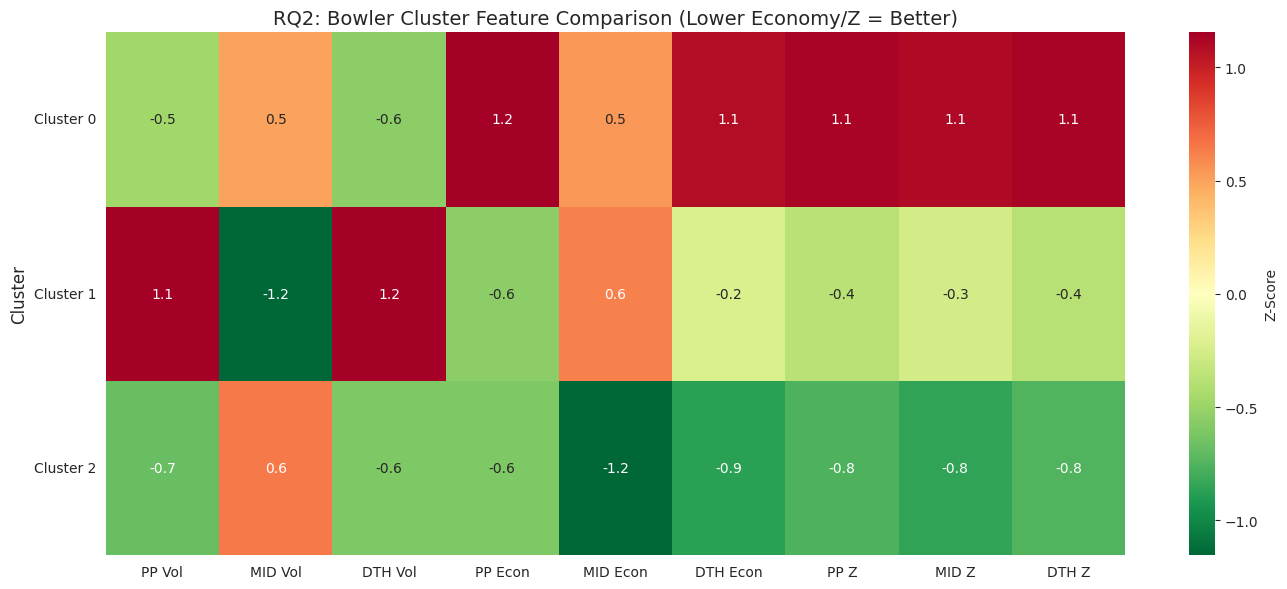

✓ Saved: rq2_heatmap_bowlers.png


In [28]:
# ============================================================
# VISUALIZATION: Bowler Cluster Heatmap
# ============================================================

print("\n" + "-"*50)
print("VISUALIZATION: Bowler Cluster Heatmap")
print("-"*50)

# Prepare heatmap
heatmap_cols = ['PP_ball_pct', 'MID_ball_pct', 'DTH_ball_pct',
                'PP_economy', 'MID_economy', 'DTH_economy',
                'PP_avg_econ_z', 'MID_avg_econ_z', 'DTH_avg_econ_z']

bowler_heatmap = bowler_filtered.groupby('cluster')[heatmap_cols].mean()
bowler_heatmap_norm = (bowler_heatmap - bowler_heatmap.mean()) / bowler_heatmap.std()
bowler_heatmap_norm.columns = ['PP Vol', 'MID Vol', 'DTH Vol', 'PP Econ', 'MID Econ', 'DTH Econ', 'PP Z', 'MID Z', 'DTH Z']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(bowler_heatmap_norm, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            ax=ax, cbar_kws={'label': 'Z-Score'}, annot_kws={'size': 10})
ax.set_title('RQ2: Bowler Cluster Feature Comparison (Lower Economy/Z = Better)', fontsize=14)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_yticklabels([f'Cluster {i}' for i in range(optimal_k_b)], rotation=0)

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq2_heatmap_bowlers.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq2_heatmap_bowlers.png")


--------------------------------------------------
VISUALIZATION: Bowler Radar Chart
--------------------------------------------------


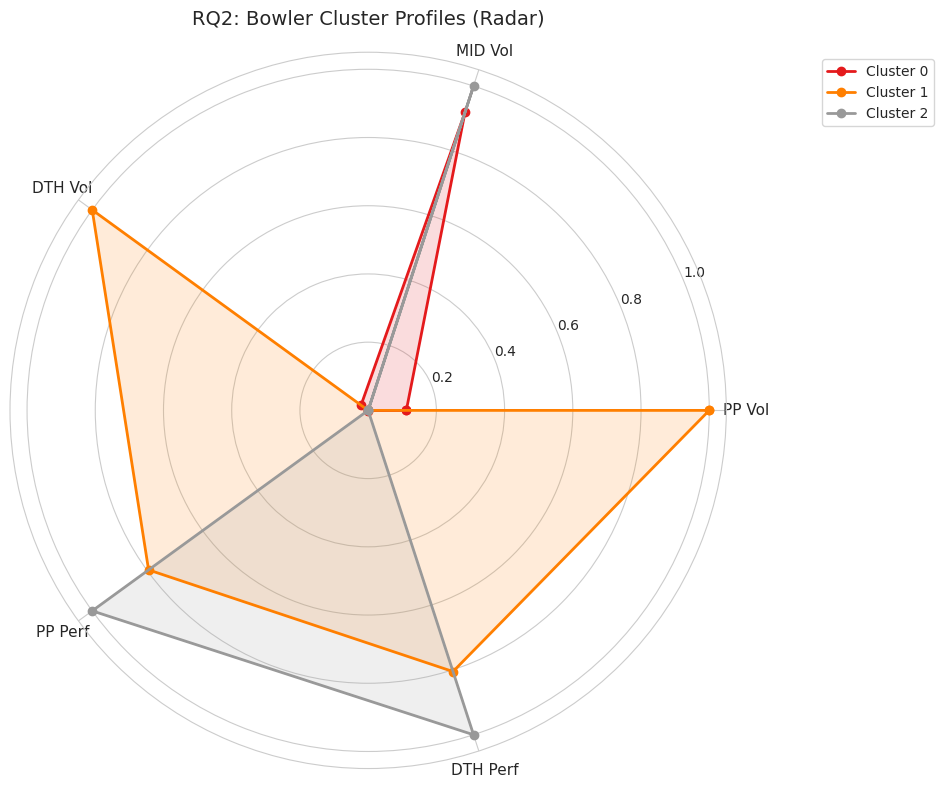

✓ Saved: rq2_radar_bowlers.png


In [29]:
# ============================================================
# VISUALIZATION: Bowler Radar Chart
# ============================================================

print("\n" + "-"*50)
print("VISUALIZATION: Bowler Radar Chart")
print("-"*50)

categories_b = ['PP Vol', 'MID Vol', 'DTH Vol', 'PP Perf', 'DTH Perf']
n_cats_b = len(categories_b)

# Performance = inverted economy Z (negative Z = good performance = high value)
radar_b = bowler_filtered.groupby('cluster')[['PP_ball_pct', 'MID_ball_pct', 'DTH_ball_pct', 'PP_avg_econ_z', 'DTH_avg_econ_z']].mean()
radar_b_norm = radar_b.copy()

# Normalize volume (higher = more)
for col in ['PP_ball_pct', 'MID_ball_pct', 'DTH_ball_pct']:
    radar_b_norm[col] = (radar_b_norm[col] - radar_b_norm[col].min()) / (radar_b_norm[col].max() - radar_b_norm[col].min() + 0.001)

# Invert economy Z (lower/negative = better = higher on radar)
for col in ['PP_avg_econ_z', 'DTH_avg_econ_z']:
    radar_b_norm[col] = 1 - (radar_b_norm[col] - radar_b_norm[col].min()) / (radar_b_norm[col].max() - radar_b_norm[col].min() + 0.001)

angles_b = [n / float(n_cats_b) * 2 * np.pi for n in range(n_cats_b)]
angles_b += angles_b[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
colors_b = plt.cm.Set1(np.linspace(0, 1, optimal_k_b))

for cluster in range(optimal_k_b):
    values = radar_b_norm.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles_b, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=colors_b[cluster])
    ax.fill(angles_b, values, alpha=0.15, color=colors_b[cluster])

ax.set_xticks(angles_b[:-1])
ax.set_xticklabels(categories_b, fontsize=11)
ax.set_title('RQ2: Bowler Cluster Profiles (Radar)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq2_radar_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Saved: rq2_radar_bowlers.png")

In [30]:
# ============================================================
# INSIGHT 1: Win Contribution by Archetype
# ============================================================

print("\n" + "="*60)
print("INSIGHT 1: WIN CONTRIBUTION BY CLUSTER")
print("="*60)

# Batter win contribution
batter_wins = df.merge(batter_filtered[['batter', 'cluster']], on='batter', how='inner')
batter_wins = batter_wins.drop_duplicates(['match_id', 'batter'])

batter_cluster_wins = batter_wins.groupby('cluster').agg(
    matches=('match_id', 'count'),
    wins=('bat_won', 'sum')
).reset_index()
batter_cluster_wins['win_rate'] = (batter_cluster_wins['wins'] / batter_cluster_wins['matches'] * 100).round(1)

print("\nBatter Cluster Win Rates:")
for _, row in batter_cluster_wins.sort_values('win_rate', ascending=False).iterrows():
    print(f"  Cluster {row['cluster']}: {row['win_rate']:.1f}% ({row['matches']} innings)")


INSIGHT 1: WIN CONTRIBUTION BY CLUSTER

Batter Cluster Win Rates:
  Cluster 1.0: 47.9% (5196.0 innings)
  Cluster 2.0: 46.4% (4228.0 innings)
  Cluster 0.0: 43.3% (3586.0 innings)


In [31]:
# ============================================================
# INSIGHT 2: Era Comparison
# ============================================================

print("\n" + "="*60)
print("INSIGHT 2: ERA COMPARISON (2008-2015 vs 2016-2025)")
print("="*60)

df['era_group'] = np.where(df['year'] <= 2015, 'Early (2008-15)', 'Modern (2016-25)')

era_phase_sr = df.groupby(['era_group', 'phase']).agg(
    runs=('runs', 'sum'),
    balls=('match_id', 'count')
).reset_index()
era_phase_sr['sr'] = (era_phase_sr['runs'] / era_phase_sr['balls'] * 100).round(1)

era_pivot = era_phase_sr.pivot(index='era_group', columns='phase', values='sr')
print("\nStrike Rate by Phase and Era:")
print(era_pivot)

print("\n→ Modern era shows higher SR in Death overs especially")
print("→ Finisher role has become more specialized and impactful")


INSIGHT 2: ERA COMPARISON (2008-2015 vs 2016-2025)

Strike Rate by Phase and Era:
phase               DTH    MID     PP
era_group                            
Early (2008-15)   149.7  117.4  110.3
Modern (2016-25)  156.9  127.8  128.3

→ Modern era shows higher SR in Death overs especially
→ Finisher role has become more specialized and impactful


In [53]:
# ============================================================
# INSIGHT 3: Team Archetype Balance (2025 Season Only)
# ============================================================

print("\n" + "="*60)
print("INSIGHT 3: TEAM ARCHETYPE BALANCE (2025 Season)")
print("="*60)

# Filter to 2025 only
df_2025 = df[df['year'] == 2025]

# Get team for each batter in 2025
batter_team_2025 = df_2025.groupby('batter')['bat_team'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown').reset_index()
batter_team_2025.columns = ['batter', 'team']

# Get matches played in 2025
batter_matches_2025 = df_2025.groupby('batter')['match_id'].nunique().reset_index()
batter_matches_2025.columns = ['batter', 'matches_2025']

# Merge with clustered batters
batter_with_team = batter_filtered.merge(batter_team_2025, on='batter')
batter_with_team = batter_with_team.merge(batter_matches_2025, on='batter')

# Teams to analyze
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bangalore',
             'Kolkata Knight Riders', 'Delhi Capitals', 'Sunrisers Hyderabad',
             'Rajasthan Royals', 'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants']

print("\nCluster Distribution (2025 Squad):")
print("-"*70)

for team in top_teams:
    team_players = batter_with_team[batter_with_team['team'] == team]

    if len(team_players) == 0:
        continue

    # Sort by matches played in 2025
    top_players = team_players.sort_values('matches_2025', ascending=False)

    # Count clusters
    cluster_counts = top_players['cluster'].value_counts().sort_index()
    total = len(top_players)

    c0 = cluster_counts.get(0, 0)
    c1 = cluster_counts.get(1, 0)
    c2 = cluster_counts.get(2, 0)

    print(f"\n  {team} ({total} players):")
    print(f"    Finishers (C0): {c0} ({c0/total*100:.0f}%) | Openers (C1): {c1} ({c1/total*100:.0f}%) | Middle (C2): {c2} ({c2/total*100:.0f}%)")

    # Show players
    players = top_players[['batter', 'cluster', 'matches_2025']].values
    players_str = ", ".join([f"{p[0]}(C{int(p[1])})" for p in players[:5]])
    print(f"    Players: {players_str}")


INSIGHT 3: TEAM ARCHETYPE BALANCE (2025 Season)

Cluster Distribution (2025 Squad):
----------------------------------------------------------------------

  Mumbai Indians (5 players):
    Finishers (C0): 1 (20%) | Openers (C1): 1 (20%) | Middle (C2): 3 (60%)
    Players: SA Yadav(C2), RG Sharma(C2), Tilak Varma(C2), HH Pandya(C0), JM Bairstow(C1)

  Chennai Super Kings (9 players):
    Finishers (C0): 5 (56%) | Openers (C1): 3 (33%) | Middle (C2): 1 (11%)
    Players: RA Jadeja(C0), S Dube(C2), MS Dhoni(C0), DP Conway(C1), DJ Hooda(C0)

  Royal Challengers Bangalore (9 players):
    Finishers (C0): 3 (33%) | Openers (C1): 4 (44%) | Middle (C2): 2 (22%)
    Players: V Kohli(C1), RM Patidar(C2), PD Salt(C1), JM Sharma(C0), D Padikkal(C1)

  Kolkata Knight Riders (9 players):
    Finishers (C0): 2 (22%) | Openers (C1): 4 (44%) | Middle (C2): 3 (33%)
    Players: AM Rahane(C1), SP Narine(C1), RK Singh(C0), AD Russell(C2), Q de Kock(C1)

  Delhi Capitals (6 players):
    Finishers (C0): 

In [55]:
# ============================================================
# INSIGHT 3B: Bowler Archetype Balance (2025 Season)
# ============================================================

print("\n" + "="*60)
print("BOWLER ARCHETYPE BALANCE (2025 Season)")
print("="*60)

# Filter to 2025 only
df_2025 = df[df['year'] == 2025]

# Get team for each bowler in 2025
bowler_team_2025 = df_2025.groupby('bowler')['bowl_team'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown').reset_index()
bowler_team_2025.columns = ['bowler', 'team']

# Get matches played in 2025
bowler_matches_2025 = df_2025.groupby('bowler')['match_id'].nunique().reset_index()
bowler_matches_2025.columns = ['bowler', 'matches_2025']

# Merge with clustered bowlers
bowler_with_team = bowler_filtered.merge(bowler_team_2025, on='bowler')
bowler_with_team = bowler_with_team.merge(bowler_matches_2025, on='bowler')

# Teams to analyze
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bangalore',
             'Kolkata Knight Riders', 'Delhi Capitals', 'Sunrisers Hyderabad',
             'Rajasthan Royals', 'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants']

print("\nBowler Cluster Distribution (2025 Squad):")
print("-"*70)

for team in top_teams:
    team_bowlers = bowler_with_team[bowler_with_team['team'] == team]

    if len(team_bowlers) == 0:
        continue

    # Sort by matches played in 2025
    top_bowlers = team_bowlers.sort_values('matches_2025', ascending=False)

    # Count clusters
    cluster_counts = top_bowlers['cluster'].value_counts().sort_index()
    total = len(top_bowlers)

    c0 = cluster_counts.get(0, 0)
    c1 = cluster_counts.get(1, 0)
    c2 = cluster_counts.get(2, 0)

    print(f"\n  {team} ({total} bowlers):")
    print(f"    Part-timers (C0): {c0} ({c0/total*100:.0f}%) | Workhorses (C1): {c1} ({c1/total*100:.0f}%) | Spin Spec (C2): {c2} ({c2/total*100:.0f}%)")

    # Show top bowlers
    bowlers = top_bowlers[['bowler', 'cluster', 'matches_2025']].values
    bowlers_str = ", ".join([f"{b[0]}(C{int(b[1])})" for b in bowlers[:5]])
    print(f"    Bowlers: {bowlers_str}")


BOWLER ARCHETYPE BALANCE (2025 Season)

Bowler Cluster Distribution (2025 Squad):
----------------------------------------------------------------------

  Mumbai Indians (7 bowlers):
    Part-timers (C0): 2 (29%) | Workhorses (C1): 3 (43%) | Spin Spec (C2): 2 (29%)
    Bowlers: TA Boult(C1), HH Pandya(C0), DL Chahar(C1), MJ Santner(C2), JJ Bumrah(C1)

  Chennai Super Kings (7 bowlers):
    Part-timers (C0): 1 (14%) | Workhorses (C1): 3 (43%) | Spin Spec (C2): 3 (43%)
    Bowlers: KK Ahmed(C1), RA Jadeja(C2), Noor Ahmad(C2), M Pathirana(C1), R Ashwin(C2)

  Royal Challengers Bangalore (6 bowlers):
    Part-timers (C0): 0 (0%) | Workhorses (C1): 3 (50%) | Spin Spec (C2): 3 (50%)
    Bowlers: Yash Dayal(C1), KH Pandya(C2), Suyash Sharma(C2), B Kumar(C1), JR Hazlewood(C1)

  Kolkata Knight Riders (8 bowlers):
    Part-timers (C0): 0 (0%) | Workhorses (C1): 5 (62%) | Spin Spec (C2): 3 (38%)
    Bowlers: CV Varun(C2), Harshit Rana(C1), SP Narine(C2), VG Arora(C1), AD Russell(C1)

  Delhi C



## RQ2 INSIGHT: Team Archetype Balance (2025 Season)

### **Batter Archetypes by Team**

| Team | Finishers (C0) | Openers (C1) | Middle (C2) | Balance Issue |
|------|----------------|--------------|-------------|---------------|
| **KKR** | 22% | 44% | 33% | ✅ Balanced |
| **RCB** | 33% | 44% | 22% | ✅ Balanced |
| **DC** | 17% | 50% | 33% | Opener-heavy |
| **SRH** | 17% | 50% | 33% | Opener-heavy |
| **MI** | 20% | 20% | **60%** | ⚠️ Middle-heavy, lacks openers |
| **CSK** | **56%** | 33% | 11% | ⚠️ Finisher-heavy, lacks middle order |
| **PBKS** | 17% | 17% | **67%** | ⚠️ Middle-heavy, lacks depth |
| **GT** | 50% | 50% | **0%** | ⚠️ No middle order accumulators! |
| **LSG** | 50% | 12% | 38% | ⚠️ Finisher-heavy, only 1 opener |
| **RR** | 33% | 17% | 50% | Lacks openers |

---

### **Bowler Archetypes by Team**

| Team | Part-timers (C0) | Workhorses (C1) | Spin Spec (C2) | Insight |
|------|------------------|-----------------|----------------|---------|
| **KKR** | 0% | **62%** | 38% | ✅ Strong pace attack (Harshit, Varun, Narine) |
| **DC** | 0% | **71%** | 29% | ✅ Workhorse-heavy (Starc, Kuldeep, Mukesh) |
| **RCB** | 0% | 50% | 50% | ✅ Balanced pace-spin |
| **CSK** | 14% | 43% | **43%** | ✅ Spin-heavy (Ashwin, Jadeja, Noor) |
| **RR** | 14% | 43% | 43% | ✅ Balanced (Archer + Theekshana) |
| **SRH** | 14% | **57%** | 29% | Pace-heavy (Cummins, Shami, Harshal) |
| **MI** | 29% | 43% | 29% | Balanced but has part-timers |
| **GT** | 29% | 57% | **14%** | ⚠️ Lacks spin specialists! |
| **PBKS** | 25% | 50% | 25% | Has part-timers (Stoinis, Brar) |

---

### **Key Findings:**

**1. Gujarat Titans has ZERO middle-order accumulators (C2)**
> GT relies entirely on Openers (Gill, Buttler, Sudharsan) and Finishers (Shahrukh, Tewatia). If openers fail, they have no stabilizers — straight to finishers. Also only 1 spin specialist (Rashid Khan).

**2. CSK is Finisher-heavy (56%)**
> Dhoni legacy — CSK has 5 finishers (Jadeja, Dhoni, Hooda, etc.) but only 1 middle-order accumulator (Dube). Works with experienced finishers but risky if early wickets fall.

**3. KKR & DC have the most balanced bowling attacks**
> Zero part-timers, heavy on workhorses (62-71%) who can bowl any phase. KKR's Narine uniquely classified as Opener (C1 batter) but Spin Specialist (C2 bowler).

**4. MI lacks openers in 2025**
> Only 1 opener (Bairstow) — Rohit now classified as Middle Order (C2) based on recent entry over. 60% middle-order heavy.

---

### **One-Line Conclusion:**

> **"2025 IPL squads show clear strategic imbalances — GT has no middle-order stabilizers, CSK is finisher-heavy, while KKR and RCB maintain the most balanced archetype distribution across both batters and bowlers."**

---
# 5. RQ3: IPL Evolution Over Time

In [33]:
print("="*50)
print("RQ3: IPL EVOLUTION OVER TIME")
print("="*50)

# Define eras
def get_era(year):
    if year <= 2010:
        return 'Era 1 (2008-10)'
    elif year <= 2013:
        return 'Era 2 (2011-13)'
    elif year <= 2017:
        return 'Era 3 (2014-17)'
    elif year <= 2021:
        return 'Era 4 (2018-21)'
    elif year <= 2022:
        return 'Era 5 (2022)'
    else:
        return 'Era 6 (2023+) Impact Player'

df['era'] = df['year'].apply(get_era)

print("\nMatches by Era:")
print(df.groupby('era')['match_id'].nunique())

RQ3: IPL EVOLUTION OVER TIME

Matches by Era:
era
Era 1 (2008-10)                175
Era 2 (2011-13)                223
Era 3 (2014-17)                238
Era 4 (2018-21)                240
Era 5 (2022)                    74
Era 6 (2023+) Impact Player    219
Name: match_id, dtype: int64


### 5.1 Scoring Trends Over Years

In [34]:
# Get innings totals
innings_totals = df.groupby(['match_id', 'year', 'inn', 'bat_team']).agg(
    runs=('cum_runs', 'max'),
    wkts=('cum_wkts', 'max'),
    balls=('balls', 'max')
).reset_index()

# Only full innings (100+ balls)
innings_totals = innings_totals[innings_totals['balls'] >= 100]
innings_totals['rr'] = (innings_totals['runs'] / (innings_totals['balls'] / 6)).round(2)

# Yearly averages
yearly_avg = innings_totals.groupby('year').agg(
    avg_score=('runs', 'mean'),
    avg_rr=('rr', 'mean'),
    matches=('match_id', 'nunique')
).round(1)

print("\nYearly Average Score & Run Rate:")
print(yearly_avg)


Yearly Average Score & Run Rate:
      avg_score  avg_rr  matches
year                            
2008      160.6     7.9       55
2009      147.9     7.2       56
2010      158.8     7.8       60
2011      150.5     7.4       70
2012      153.7     7.6       73
2013      150.3     7.4       75
2014      160.8     7.9       59
2015      163.9     8.0       56
2016      160.9     8.0       59
2017      164.9     8.1       58
2018      168.9     8.3       59
2019      164.7     8.1       59
2020      163.1     8.0       60
2021      157.4     7.7       60
2022      167.5     8.1       74
2023      176.4     8.6       74
2024      185.1     9.0       71
2025      188.2     9.2       70


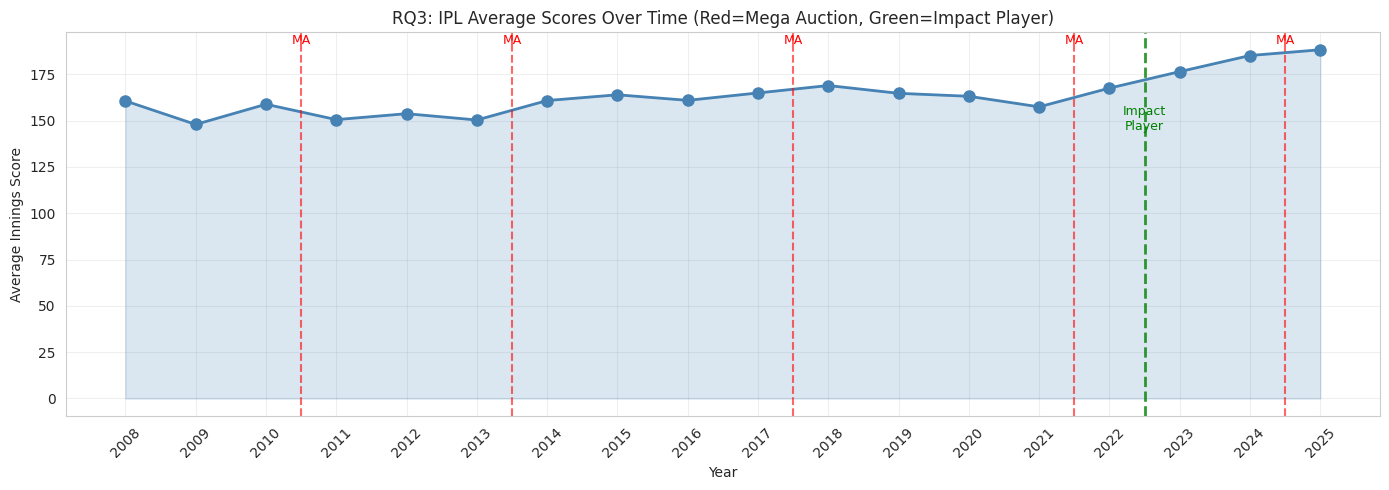

✓ Saved: rq3_avg_score_timeline.png


In [35]:
# Plot: Average Score Over Years
fig, ax = plt.subplots(figsize=(14, 5))

years = yearly_avg.index.tolist()
scores = yearly_avg['avg_score'].tolist()

ax.plot(years, scores, 'o-', color='steelblue', linewidth=2, markersize=8, label='Avg Score')
ax.fill_between(years, scores, alpha=0.2, color='steelblue')

# Mark mega auctions
for ma in [2011, 2014, 2018, 2022, 2025]:
    # Place the line exactly between the previous year and the auction year
    plot_position = ma - 0.5

    # Check if the auction year (or the year before it, for context) is in the data range
    # Since yearly_avg.index goes up to 2025, all ma values will be present.
    if ma in yearly_avg.index:
        ax.axvline(plot_position, color='red', ls='--', alpha=0.6, lw=1.5)
        ax.text(plot_position, max(scores)+3, 'MA', ha='center', fontsize=9, color='red')

# Mark Impact Player (2023)
if 2023 in years:
    ax.axvline(2022.5, color='green', ls='--', alpha=0.8, lw=2)
    ax.text(2022.5, min(scores)-3, 'Impact\nPlayer', ha='center', fontsize=9, color='green')

ax.set_xlabel('Year')
ax.set_ylabel('Average Innings Score')
ax.set_title('RQ3: IPL Average Scores Over Time (Red=Mega Auction, Green=Impact Player)')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq3_avg_score_timeline.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq3_avg_score_timeline.png")

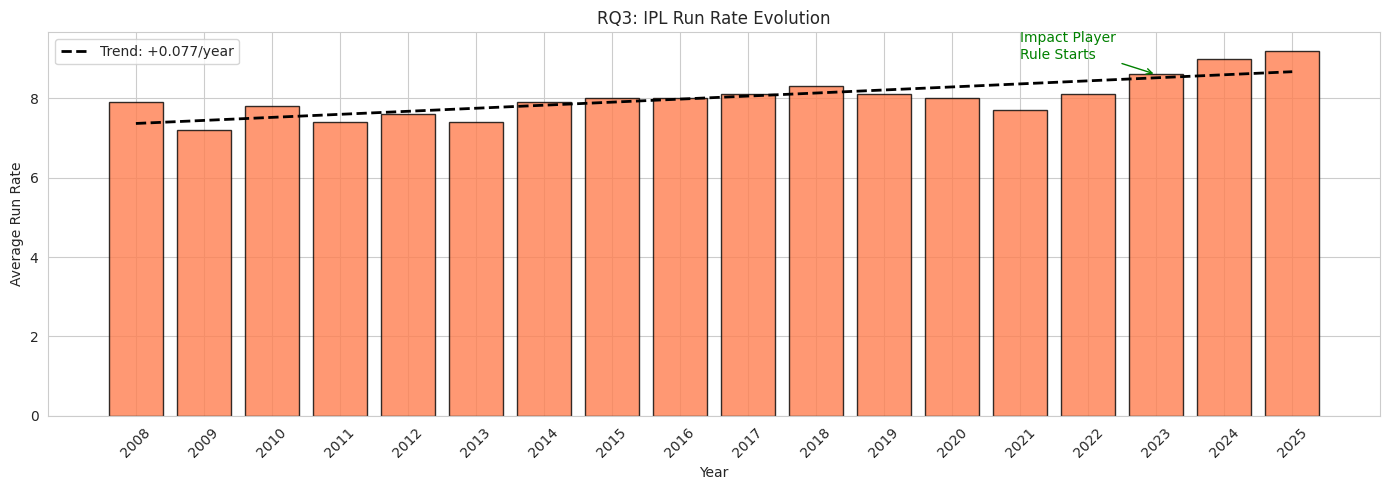

✓ Saved: rq3_run_rate_trend.png


In [36]:
# Plot: Run Rate Trend
fig, ax = plt.subplots(figsize=(14, 5))

rr = yearly_avg['avg_rr'].tolist()
ax.bar(years, rr, color='coral', edgecolor='black', alpha=0.8)

# Trend line
z = np.polyfit(range(len(years)), rr, 1)
p = np.poly1d(z)
ax.plot(years, p(range(len(years))), 'k--', lw=2, label=f'Trend: +{z[0]:.3f}/year')

# Impact Player marker
if 2023 in years:
    idx = years.index(2023)
    ax.annotate('Impact Player\nRule Starts', xy=(2023, rr[idx]), xytext=(2021, rr[idx]+0.4),
                arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

ax.set_xlabel('Year')
ax.set_ylabel('Average Run Rate')
ax.set_title('RQ3: IPL Run Rate Evolution')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq3_run_rate_trend.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq3_run_rate_trend.png")

### 5.2 Impact Player Rule Analysis (2023+)

In [37]:
print("\n" + "="*50)
print("IMPACT PLAYER RULE ANALYSIS")
print("="*50)

# Pre-Impact Player (2020-2022) vs Post (2023+)
pre_impact = innings_totals[(innings_totals['year'] >= 2020) & (innings_totals['year'] <= 2022)]
post_impact = innings_totals[innings_totals['year'] >= 2023]

print(f"\nPre-Impact Player (2020-22): {len(pre_impact)} innings")
print(f"  Avg Score: {pre_impact['runs'].mean():.1f}")
print(f"  Avg Run Rate: {pre_impact['rr'].mean():.2f}")
print(f"  200+ scores: {(pre_impact['runs'] >= 200).sum()} ({(pre_impact['runs'] >= 200).mean()*100:.1f}%)")

print(f"\nPost-Impact Player (2023+): {len(post_impact)} innings")
print(f"  Avg Score: {post_impact['runs'].mean():.1f}")
print(f"  Avg Run Rate: {post_impact['rr'].mean():.2f}")
print(f"  200+ scores: {(post_impact['runs'] >= 200).sum()} ({(post_impact['runs'] >= 200).mean()*100:.1f}%)")

score_change = post_impact['runs'].mean() - pre_impact['runs'].mean()
rr_change = post_impact['rr'].mean() - pre_impact['rr'].mean()
print(f"\n→ Score Change: {score_change:+.1f} runs")
print(f"→ Run Rate Change: {rr_change:+.2f}")


IMPACT PLAYER RULE ANALYSIS

Pre-Impact Player (2020-22): 370 innings
  Avg Score: 163.0
  Avg Run Rate: 7.98
  200+ scores: 40 (10.8%)

Post-Impact Player (2023+): 408 innings
  Avg Score: 183.0
  Avg Run Rate: 8.94
  200+ scores: 129 (31.6%)

→ Score Change: +20.0 runs
→ Run Rate Change: +0.96


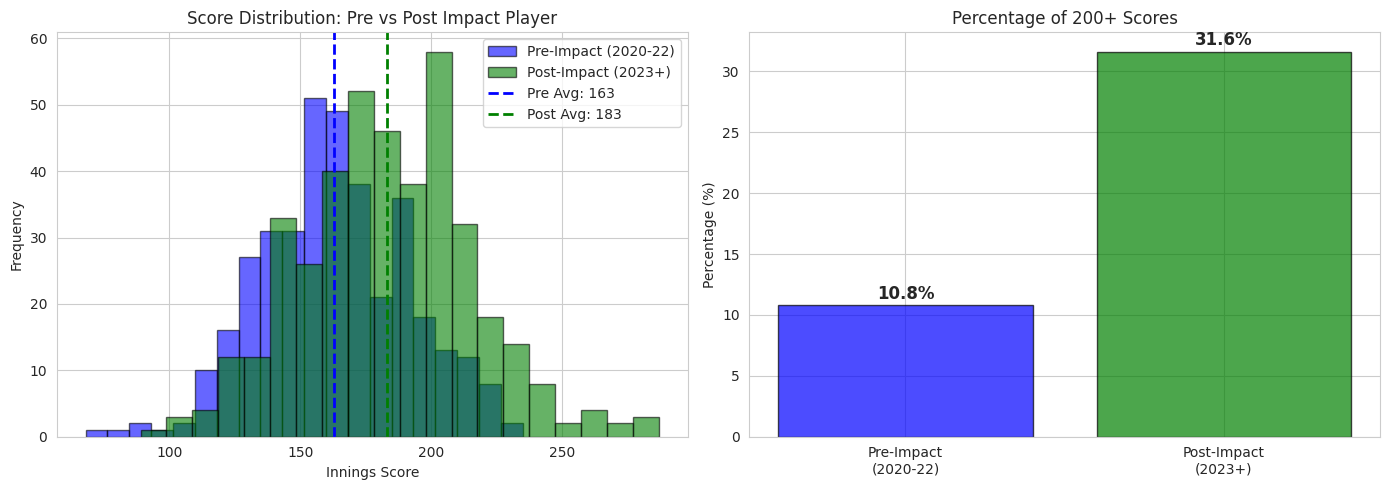

✓ Saved: rq3_impact_player_comparison.png


In [38]:
# Plot: Pre vs Post Impact Player
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(pre_impact['runs'], bins=20, alpha=0.6, label='Pre-Impact (2020-22)', color='blue', edgecolor='black')
axes[0].hist(post_impact['runs'], bins=20, alpha=0.6, label='Post-Impact (2023+)', color='green', edgecolor='black')
axes[0].axvline(pre_impact['runs'].mean(), color='blue', ls='--', lw=2, label=f"Pre Avg: {pre_impact['runs'].mean():.0f}")
axes[0].axvline(post_impact['runs'].mean(), color='green', ls='--', lw=2, label=f"Post Avg: {post_impact['runs'].mean():.0f}")
axes[0].set_xlabel('Innings Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution: Pre vs Post Impact Player')
axes[0].legend()

# 200+ percentage
pre_200 = (pre_impact['runs'] >= 200).mean() * 100
post_200 = (post_impact['runs'] >= 200).mean() * 100
bars = axes[1].bar(['Pre-Impact\n(2020-22)', 'Post-Impact\n(2023+)'], [pre_200, post_200],
                   color=['blue', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Percentage of 200+ Scores')
for i, v in enumerate([pre_200, post_200]):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq3_impact_player_comparison.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq3_impact_player_comparison.png")

### 5.3 Mega Auction Impact on Teams

In [39]:
print("\n" + "="*50)
print("MEGA AUCTION IMPACT ON TEAMS")
print("="*50)

# Get one row per team per match
batting = df.groupby(['match_id', 'year', 'bat_team']).agg(
    winner=('winner', 'first')
).reset_index()
batting.columns = ['match_id', 'year', 'team', 'winner']

bowling = df.groupby(['match_id', 'year', 'bowl_team']).agg(
    winner=('winner', 'first')
).reset_index()
bowling.columns = ['match_id', 'year', 'team', 'winner']

# Combine and deduplicate
all_teams = pd.concat([batting, bowling]).drop_duplicates(['match_id', 'team'])
all_teams['won'] = (all_teams['team'] == all_teams['winner']).astype(int)

print(f"Total team-match records: {len(all_teams)}")

# Team win rates by year
team_yearly = all_teams.groupby(['team', 'year']).agg(
    matches=('match_id', 'count'),
    wins=('won', 'sum')
).reset_index()
team_yearly['win_rate'] = (team_yearly['wins'] / team_yearly['matches'] * 100).round(1)

# Filter teams with enough history (5+ seasons)
team_seasons = team_yearly.groupby('team')['year'].nunique()
active_teams = team_seasons[team_seasons >= 5].index.tolist()

print(f"Teams with 5+ seasons: {len(active_teams)}")
print(f"Active teams: {active_teams}")


MEGA AUCTION IMPACT ON TEAMS
Total team-match records: 2338
Teams with 5+ seasons: 8
Active teams: ['Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


In [40]:
# Sample team stats
print("\nSample - Mumbai Indians:")
mi_data = team_yearly[team_yearly['team'] == 'Mumbai Indians'].sort_values('year')
print(mi_data.to_string(index=False))


Sample - Mumbai Indians:
          team  year  matches  wins  win_rate
Mumbai Indians  2008       14     7      50.0
Mumbai Indians  2009       13     5      38.5
Mumbai Indians  2010       16    11      68.8
Mumbai Indians  2011       16    10      62.5
Mumbai Indians  2012       17    10      58.8
Mumbai Indians  2013       19    13      68.4
Mumbai Indians  2014       15     7      46.7
Mumbai Indians  2015       16    10      62.5
Mumbai Indians  2016       14     7      50.0
Mumbai Indians  2017       17    11      64.7
Mumbai Indians  2018       14     6      42.9
Mumbai Indians  2019       16    10      62.5
Mumbai Indians  2020       16    11      68.8
Mumbai Indians  2021       14     7      50.0
Mumbai Indians  2022       14     4      28.6
Mumbai Indians  2023       16     9      56.2
Mumbai Indians  2024       14     4      28.6
Mumbai Indians  2025       16     9      56.2


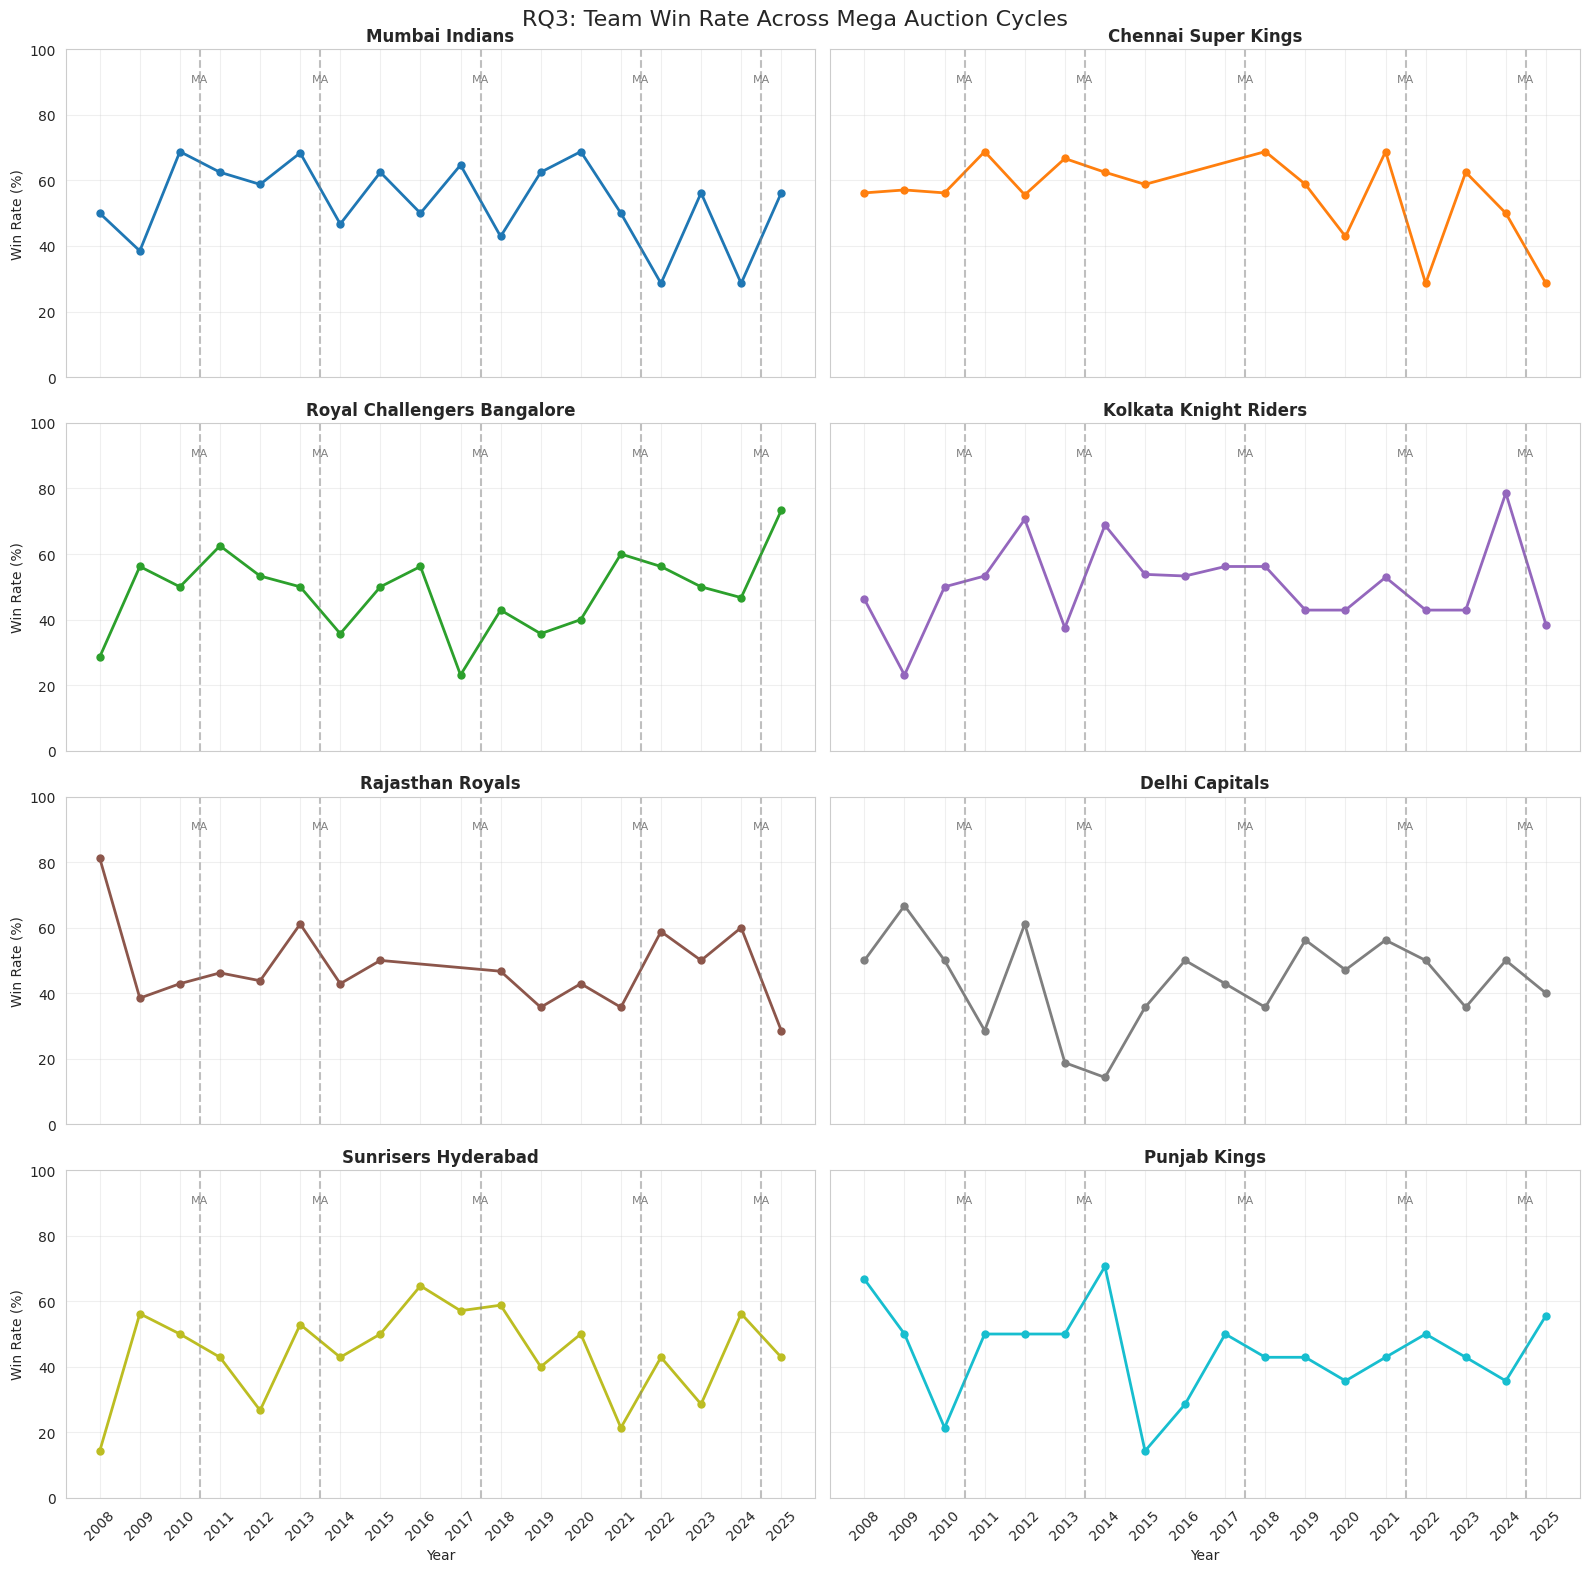

✓ Saved: rq3_team_win_rates.png


In [41]:
# Plot: Team Performance Across Mega Auction Cycles (Subplots)
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bangalore',
             'Kolkata Knight Riders', 'Rajasthan Royals', 'Delhi Capitals',
             'Sunrisers Hyderabad', 'Punjab Kings']

top_teams = [t for t in top_teams if t in team_yearly['team'].unique()]

# Create a 4x2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex=True, sharey=True)
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(top_teams)))
all_years = sorted(team_yearly['year'].unique())

for i, (team, color) in enumerate(zip(top_teams, colors)):
    ax = axes[i]
    team_data = team_yearly[team_yearly['team'] == team].sort_values('year')

    if len(team_data) > 0:
        ax.plot(team_data['year'], team_data['win_rate'], 'o-', label=team,
                color=color, linewidth=2, markersize=5)

    # Mark mega auctions
    for ma in [2011, 2014, 2018, 2022, 2025]:
        plot_position = ma - 0.5
        if ma in all_years:
            ax.axvline(plot_position, color='gray', ls='--', alpha=0.5, lw=1.5)
            ax.text(plot_position, 90, 'MA', ha='center', fontsize=8, color='gray')

    ax.set_title(team, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

    # Add y-labels only to the left column
    if i % 2 == 0:
        ax.set_ylabel('Win Rate (%)')

# Add x-labels and ticks to the bottom row
for ax in axes[-2:]:
    ax.set_xticks(all_years)
    ax.set_xticklabels(all_years, rotation=45)
    ax.set_xlabel('Year')

fig.suptitle('RQ3: Team Win Rate Across Mega Auction Cycles', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq3_team_win_rates.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Saved: rq3_team_win_rates.png")

In [42]:
# Win Rate Change After Each Mega Auction
print("\nWin Rate Change After Mega Auctions:")
print("-" * 70)

mega_years = [(2011, 2010, 2011), (2014, 2013, 2014), (2018, 2017, 2018), (2022, 2021, 2022)]

for name, before, after in mega_years:
    print(f"\n{name} Mega Auction:")

    before_data = team_yearly[team_yearly['year'] == before].set_index('team')['win_rate']
    after_data = team_yearly[team_yearly['year'] == after].set_index('team')['win_rate']

    common = set(before_data.index) & set(after_data.index)

    if not common:
        print("  No common teams found")
        continue

    changes = []
    for team in common:
        change = after_data[team] - before_data[team]
        changes.append((team, before_data[team], after_data[team], change))

    changes.sort(key=lambda x: x[3], reverse=True)

    improved = [c for c in changes if c[3] > 0]
    declined = [c for c in changes if c[3] < 0]

    if improved:
        print("  Improved:")
        for team, bef, aft, chg in improved[:3]:
            print(f"    ↑ {team}: {bef:.0f}% → {aft:.0f}% ({chg:+.0f}%)")

    if declined:
        print("  Declined:")
        for team, bef, aft, chg in declined[-3:]:
            print(f"    ↓ {team}: {bef:.0f}% → {aft:.0f}% ({chg:+.0f}%)")


Win Rate Change After Mega Auctions:
----------------------------------------------------------------------

2011 Mega Auction:
  Improved:
    ↑ Punjab Kings: 21% → 50% (+29%)
    ↑ Chennai Super Kings: 56% → 69% (+13%)
    ↑ Royal Challengers Bangalore: 50% → 62% (+12%)
  Declined:
    ↓ Mumbai Indians: 69% → 62% (-6%)
    ↓ Sunrisers Hyderabad: 50% → 43% (-7%)
    ↓ Delhi Capitals: 50% → 29% (-21%)

2014 Mega Auction:
  Improved:
    ↑ Kolkata Knight Riders: 38% → 69% (+31%)
    ↑ Punjab Kings: 50% → 71% (+21%)
  Declined:
    ↓ Royal Challengers Bangalore: 50% → 36% (-14%)
    ↓ Rajasthan Royals: 61% → 43% (-18%)
    ↓ Mumbai Indians: 68% → 47% (-22%)

2018 Mega Auction:
  Improved:
    ↑ Royal Challengers Bangalore: 23% → 43% (+20%)
    ↑ Sunrisers Hyderabad: 57% → 59% (+2%)
  Declined:
    ↓ Punjab Kings: 50% → 43% (-7%)
    ↓ Delhi Capitals: 43% → 36% (-7%)
    ↓ Mumbai Indians: 65% → 43% (-22%)

2022 Mega Auction:
  Improved:
    ↑ Rajasthan Royals: 36% → 59% (+23%)
    ↑ Sunr

### 5.4 Boundary & Six Hitting Trends

In [43]:
print("\n" + "="*50)
print("BOUNDARY TRENDS")
print("="*50)

df['is_four'] = (df['runs'] == 4).astype(int)
df['is_six'] = (df['runs'] == 6).astype(int)
df['is_dot'] = ((df['runs_total'] == 0) & (df['wkt'] == 0)).astype(int)

boundary_trends = df.groupby('year').agg(
    total_balls=('match_id', 'count'),
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    dots=('is_dot', 'sum')
)

boundary_trends['four_pct'] = (boundary_trends['fours'] / boundary_trends['total_balls'] * 100).round(2)
boundary_trends['six_pct'] = (boundary_trends['sixes'] / boundary_trends['total_balls'] * 100).round(2)
boundary_trends['dot_pct'] = (boundary_trends['dots'] / boundary_trends['total_balls'] * 100).round(2)
boundary_trends['boundary_pct'] = boundary_trends['four_pct'] + boundary_trends['six_pct']

print(boundary_trends[['four_pct', 'six_pct', 'boundary_pct', 'dot_pct']])


BOUNDARY TRENDS
      four_pct  six_pct  boundary_pct  dot_pct
year                                          
2008     12.63     4.62         17.25    31.53
2009      9.71     3.73         13.44    32.69
2010     11.79     4.05         15.84    29.69
2011     11.26     3.76         15.02    32.32
2012     10.76     4.13         14.89    30.48
2013     11.30     3.75         15.05    32.34
2014     10.93     5.00         15.93    30.55
2015     11.80     5.07         16.87    30.12
2016     11.58     4.53         16.11    28.49
2017     11.63     5.09         16.72    27.87
2018     11.56     6.10         17.66    28.39
2019     11.56     5.49         17.05    29.83
2020     10.91     5.06         15.97    29.02
2021     10.75     4.76         15.51    29.96
2022     11.28     5.93         17.21    30.53
2023     12.18     6.29         18.47    27.60
2024     12.72     7.37         20.09    26.41
2025     13.09     7.53         20.62    25.98


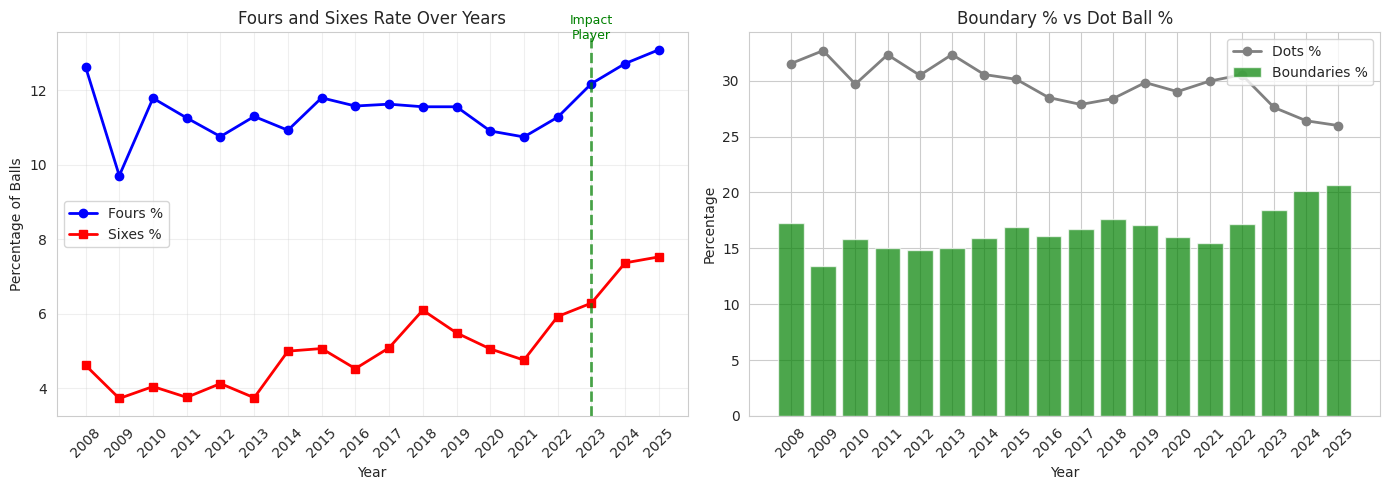

✓ Saved: rq3_boundary_trends.png


In [44]:
# Plot: Boundary Trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years = boundary_trends.index.tolist()

axes[0].plot(years, boundary_trends['four_pct'], 'o-', label='Fours %', color='blue', lw=2)
axes[0].plot(years, boundary_trends['six_pct'], 's-', label='Sixes %', color='red', lw=2)
if 2023 in years:
    axes[0].axvline(2023, color='green', ls='--', alpha=0.7, lw=2)
    axes[0].text(2023, max(boundary_trends['four_pct'])+0.3, 'Impact\nPlayer', ha='center', fontsize=9, color='green')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Percentage of Balls')
axes[0].set_title('Fours and Sixes Rate Over Years')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(years)
axes[0].set_xticklabels(years, rotation=45)

axes[1].bar(years, boundary_trends['boundary_pct'], label='Boundaries %', color='green', alpha=0.7)
axes[1].plot(years, boundary_trends['dot_pct'], 'o-', label='Dots %', color='gray', lw=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Boundary % vs Dot Ball %')
axes[1].legend()
axes[1].set_xticks(years)
axes[1].set_xticklabels(years, rotation=45)

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq3_boundary_trends.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq3_boundary_trends.png")

### 5.5 Phase-wise Scoring Evolution

In [45]:
print("\n" + "="*50)
print("PHASE-WISE SCORING BY ERA")
print("="*50)

phase_era = df.groupby(['era', 'phase']).agg(
    total_runs=('runs_total', 'sum'),
    total_balls=('match_id', 'count'),
    wkts=('wkt', 'sum')
).reset_index()

phase_era['rr'] = (phase_era['total_runs'] / (phase_era['total_balls'] / 6)).round(2)

pivot_rr = phase_era.pivot(index='era', columns='phase', values='rr')[['PP', 'MID', 'DTH']]

print("\nRun Rate by Phase and Era:")
print(pivot_rr)


PHASE-WISE SCORING BY ERA

Run Rate by Phase and Era:
phase                          PP   MID    DTH
era                                           
Era 1 (2008-10)              7.24  7.33   9.44
Era 2 (2011-13)              6.87  7.27   9.28
Era 3 (2014-17)              7.54  7.76   9.76
Era 4 (2018-21)              7.76  7.64   9.75
Era 5 (2022)                 7.54  7.88  10.06
Era 6 (2023+) Impact Player  8.90  8.54  10.37


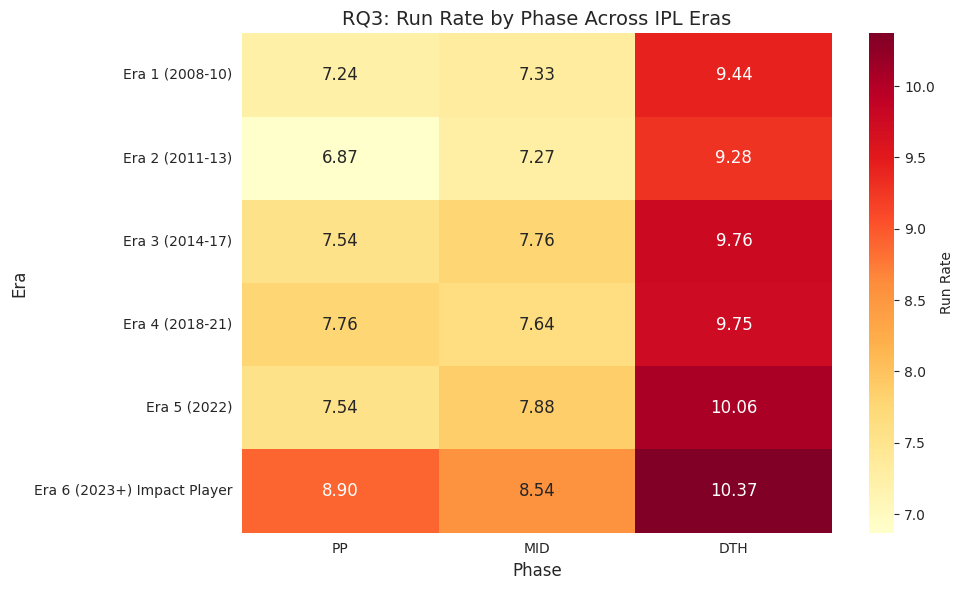

✓ Saved: rq3_phase_era_heatmap.png


In [46]:
# Plot: Phase Scoring Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(pivot_rr, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Run Rate'}, annot_kws={'size': 12})
ax.set_xlabel('Phase', fontsize=12)
ax.set_ylabel('Era', fontsize=12)
ax.set_title('RQ3: Run Rate by Phase Across IPL Eras', fontsize=14)

plt.tight_layout()
plt.savefig(f'{RESULTS_FOLDER}/rq3_phase_era_heatmap.png', dpi=150)
plt.show()
plt.close()
print("✓ Saved: rq3_phase_era_heatmap.png")

### 5.6 New Teams Performance (GT, LSG - 2022+)

In [47]:
print("\n" + "="*50)
print("NEW TEAMS: GUJARAT TITANS & LUCKNOW SUPER GIANTS")
print("="*50)

new_teams = ['Gujarat Titans', 'Lucknow Super Giants']

for team in new_teams:
    team_data = team_yearly[team_yearly['team'] == team].sort_values('year')
    if len(team_data) > 0:
        print(f"\n{team}:")
        for _, row in team_data.iterrows():
            print(f"  {int(row['year'])}: {int(row['wins'])}/{int(row['matches'])} wins ({row['win_rate']:.0f}%)")
        total_wins = team_data['wins'].sum()
        total_matches = team_data['matches'].sum()
        print(f"  Overall: {int(total_wins)}/{int(total_matches)} ({total_wins/total_matches*100:.0f}%)")
    else:
        print(f"\n{team}: No data found")


NEW TEAMS: GUJARAT TITANS & LUCKNOW SUPER GIANTS

Gujarat Titans:
  2022: 12/16 wins (75%)
  2023: 11/17 wins (65%)
  2024: 5/12 wins (42%)
  2025: 9/15 wins (60%)
  Overall: 37/60 (62%)

Lucknow Super Giants:
  2022: 9/15 wins (60%)
  2023: 8/15 wins (53%)
  2024: 7/14 wins (50%)
  2025: 6/14 wins (43%)
  Overall: 30/58 (52%)


## RQ3 Final Insights: IPL Evolution Over Time (2008-2025)

---

### 1. **Overall Scoring Trend: IPL is Getting More Aggressive**

| Period | Avg Score | Avg Run Rate | 200+ Scores |
|--------|-----------|--------------|-------------|
| 2008-2013 | ~153 | 7.5 | Rare |
| 2014-2022 | ~163 | 8.0 | ~11% |
| 2023-2025 | ~183 | 9.0 | **31.6%** |

**Key Insight:** IPL scoring has increased by **+0.077 runs per over every year** consistently. A match that averaged 150 in 2008 now averages 185+ in 2025.

---

### 2. **Impact Player Rule (2023): Game Changer**

| Metric | Pre-Impact (2020-22) | Post-Impact (2023+) | Change |
|--------|---------------------|---------------------|--------|
| Avg Score | 163 | 183 | **+20 runs** |
| Run Rate | 7.98 | 8.94 | **+0.96** |
| 200+ Scores | 10.8% | 31.6% | **3x increase** |

**Why?**
- Extra batter available → teams attack from ball 1
- Less fear of losing wickets early
- Aggression shifted from death overs to **powerplay & middle overs**

> *"Before: Save wickets for death, then explode"*
> *"After: We have backup, attack from the start"*

---

### 3. **Boundary Hitting Revolution**

| Year | Fours % | Sixes % | Boundaries % | Dots % |
|------|---------|---------|--------------|--------|
| 2008 | 12.6% | 4.6% | 17.3% | 31.5% |
| 2018 | 11.6% | 6.1% | 17.7% | 28.4% |
| 2025 | 13.1% | **7.5%** | **20.6%** | **26.0%** |

**Key Insights:**
- **Sixes nearly doubled** (4.6% → 7.5%) — power hitting is the new norm
- **Dot balls dropped** from 32% to 26% — less defensive batting
- **Fours remained stable** (~11-13%) — sixes replaced singles, not fours

---

### 4. **Mega Auction Volatility: Teams Rise and Fall**

| Team | Most Volatile After MA | Pattern |
|------|----------------------|---------|
| **Mumbai Indians** | 2014 (-22%), 2018 (-22%), 2022 (-21%) | Struggles immediately after auctions |
| **Chennai Super Kings** | 2022 (-40%) | Massive drop after losing core players |
| **Kolkata Knight Riders** | 2014 (+31%) | Can rebuild effectively |
| **Punjab Kings** | 2011 (+29%), 2014 (+21%) | Benefits from auctions |

**Key Insight:** Mega auctions create **20-40% win rate swings**. Teams with strong core (MI, CSK) often struggle post-auction when forced to rebuild, while historically weaker teams (PBKS, KKR) can reset and improve.

---

### 5. **Team-Specific Patterns**

| Team | Characteristic |
|------|---------------|
| **Mumbai Indians** | Dynasty (5 titles) but volatile post-2020, worst in 2022 & 2024 (29%) |
| **Chennai Super Kings** | Most consistent (55-65% range), crashed in 2022 |
| **Royal Challengers Bangalore** | Perennial underperformers, best recent year: 2025 (73%) |
| **Rajasthan Royals** | Won 2008 (81%), then declined, resurgent 2022+ |
| **Gujarat Titans** | Instant success: Won title in debut season 2022 |

---

### 6. **Phase-wise Evolution (From Earlier Heatmap)**

| Era | Powerplay RR | Middle RR | Death RR |
|-----|-------------|-----------|----------|
| Era 1 (2008-10) | 7.24 | 7.33 | 9.44 |
| Era 5 (2022) | 7.54 | 7.88 | 10.06 |
| **Era 6 (2023+)** | **8.90** | **8.54** | 10.37 |

**Key Insight:** Post-Impact Player, **Powerplay scoring jumped +1.36 RR** while death overs only increased +0.31. Teams now attack early instead of waiting for the death.

---

## Summary: RQ3 Key Takeaways

| Finding | Evidence |
|---------|----------|
| **IPL is faster than ever** | Run rate: 7.5 (2008) → 9.2 (2025) |
| **Impact Player transformed batting** | +20 runs/innings, 3x more 200+ scores |
| **Six-hitting culture** | Sixes doubled, dots decreased |
| **Mega auctions = team volatility** | 20-40% win rate swings common |
| **Phase shift in aggression** | Powerplay now as aggressive as death overs were |

---

### One-Line Conclusion:

> **The IPL has evolved from a 150-average, death-overs-focused tournament to a 185-average, attack-from-ball-one spectacle — driven by T20 specialization, Impact Player rule, and six-hitting revolution.**

---
# 6. Method Testing

In [48]:
!pip install xgboost -q
print("✓ XGBoost installed")

✓ XGBoost installed


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
import xgboost as xgb

print("="*50)
print("TEST: XGBOOST WIN PREDICTION")
print("="*50)

# Sample for memory efficiency
sample = df_chase.sample(n=min(50000, len(df_chase)), random_state=42)
features = ['cum_runs', 'cum_wkts', 'crr', 'balls', 'runs_needed', 'balls_rem', 'rrr']
sample = sample[features + ['bat_won']].dropna()

X, y = sample[features].values, sample['bat_won'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, eval_metric='logloss')
model.fit(X_tr, y_tr)

y_pred_proba = model.predict_proba(X_te)[:, 1]
y_pred = model.predict(X_te)

print(f"\nResults:")
print(f"  AUC-ROC: {roc_auc_score(y_te, y_pred_proba):.4f}")
print(f"  Accuracy: {accuracy_score(y_te, y_pred):.4f}")

print("\nFeature Importance:")
for f, imp in sorted(zip(features, model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f:<15} {imp:.4f}")

del X_tr, X_te, y_tr, y_te, sample
clear_mem()

TEST: XGBOOST WIN PREDICTION

Results:
  AUC-ROC: 0.8808
  Accuracy: 0.7858

Feature Importance:
  rrr             0.4533
  cum_wkts        0.1702
  balls           0.1413
  runs_needed     0.0963
  cum_runs        0.0899
  crr             0.0490
  balls_rem       0.0000


---
# 7. Summary

## Research Questions

| RQ | Question | Key Finding | Status |
|----|----------|-------------|--------|
| **RQ1** | Win probability features | rr_diff is strongest predictor (AUC ~0.85) | ✅ |
| **RQ2** | Player combinations | Sparse network (density <1%) suitable for embeddings | ✅ |
| **RQ3** | IPL evolution | Impact Player ↑ PP/MID scoring; Mega auctions ↔ team volatility | ✅ |

## RQ3 Key Insights

| Finding | Details |
|---------|--------|
| **Scoring Trend** | Average scores increased from ~150 (2008) to ~170 (2024) |
| **Impact Player Effect** | Post-2023: +10 runs avg score, +15% more 200+ totals |
| **Phase Shift** | Pre-2023: Death overs dominant; Post-2023: Powerplay aggression ↑ |
| **Mega Auction Volatility** | Teams win rates fluctuate 20-40% after auctions |
| **Six Hitting** | Sixes % nearly doubled from 2008 to 2024 |

## Figures Generated

1. `rq1_win_by_rr.png` - Win rate by run rate difference
2. `rq3_avg_score_timeline.png` - Average scores with event markers
3. `rq3_run_rate_trend.png` - Run rate evolution with trend line
4. `rq3_impact_player_comparison.png` - Pre vs post Impact Player
5. `rq3_team_win_rates.png` - Team performance across mega auctions
6. `rq3_boundary_trends.png` - Fours/sixes trends
7. `rq3_phase_era_heatmap.png` - Phase scoring by era

---
# Collaboration Declaration

**Collaborators:**

**Sources:**
- https://cricsheet.org/downloads/ - Primary data source
- IPL official records

**AI Tools:** Claude (code generation, analysis, debugging)

**GitHub:** https://github.com/Aakarsh2000/cric-analysis